# LLM Evaluation for AI in Education

## 📖 Background
Artificial Intelligence (AI) is rapidly transforming education by providing students with instant access to information and adaptive learning tools. Still, it also introduces significant risks, such as the spread of misinformation and fabricated content. Research indicates that large language models (LLMs) often confidently generate factually incorrect or “hallucinated” responses, which can mislead learners and erode trust in digital learning platforms. 

The 4th Annual Data4Good Competition challenges participants to develop innovative analytics solutions to detect and improve factuality in AI-generated educational content, ensuring that AI advances knowledge rather than confusion.

## 💾 The data

This project demonstrates LLM Evaluation using a dataset of Data4Good Case Challenge.
The data provided is a Questions/Answer dataset to determine if the answer is factual, not factual (contradiction), or irrelevant to the question.


- Question: The question asked/prompted for
- Context: Relevant contextual support for the question
- Answer: The answer provided by an AI
- Type:  A categorical variable with three possible levels – Factual, Contradiction, Irrelevant:
  - Factual: the answer is correct
  - Contradiction: the answer is incorrect
  - Irrelevant: the answer has nothing to do with the question
  
There are 21,021 examples in the dataset (`data/train.json`) that we experimented with. 


The test dataset (`data/test.json`) contains 2000 examples that we predict as one of the three provided classes.

# Overall Approach

The evaluation pipeline is executed on an Azure VM, using Azure Foundry OpenAI models for high performance in evaluation.

The overall sequence of steps we followed are:
- Exploratory Data Analysis to understand the training data, LLM answer category distributions and uncover insights useful for our solution

- Data pre-processing and Feature Engineering to generate useful features , using Natural Language processing and evaluation metrics

- LLM as a judge, using numeric features generated as well as to judge semantic meaning and factuality of LLM answers with respect to given contexts. 

- Analysis of evaluation results and improvements

- Refining the LLM judge using a Named ENtity Recognition (NER) model

- Final result analysis

- Recording the LLM judge outputs on test data


### Previewing the Training Data

Let's load and preview the `train.json` dataset to understand its structure and contents.

In [1]:
import pandas as pd
import json

# Load the train.json file
data_path = "data/train.json"
with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to DataFrame
train_df = pd.DataFrame(data)

# Show the first 50 rows
train_df.head(50)

,answer,type,context,question
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...
5,The process that can increase solar energy pot...,factual,,What is the process called that can increase s...
6,The main focus of the 5th season is the Digita...,factual,"After a three-year hiatus, a fifth Digimon ser...",What was the main focus of the 5th season?
7,The mean annual temperature in Hyderabad is 26...,factual,Hyderabad has a tropical wet and dry climate (...,What is the mean yearly temperature in Hyderab...
8,The issue of through traffic benefits can aris...,factual,Network effects are a large factor with electr...,Where can the issue of through traffic benefit...
9,Montini's office received nearly ten million i...,irrelevant,,Fireworks are discharged on New Year's Eve fro...


In [20]:
# Load the test.json file
data_path = "data/test.json"
with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to DataFrame
test_df = pd.DataFrame(data)

In [21]:
test_df.head()

,ID,answer,type,context,question
0,1,"In the mid-19th century, the Bronx was referre...",,The Bronx street grid is irregular. Like the n...,What was the Bronx called in the mid-19th cent...
1,2,"Beyoncé's father, Mathew Knowles, began managi...",,,When did Beyoncé begin to manage the girl group?
2,3,Dionysus was similar to the Roman god Bacchus.,,"While the new plebeian nobility made social, p...",To what Roman god was Dionysus similar?
3,4,The most crucial defense in preventing the spr...,,"Techniques like hand washing, wearing gowns, a...",What is the most important defense against the...
4,5,The third largest long term acute care provide...,,The Baylor College of Medicine has annually be...,What is the third largest acute care center in...


# Exploratory Data Analysis

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21021 entries, 0 to 21020
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   answer    21021 non-null  object
 1   type      21021 non-null  object
 2   context   21021 non-null  object
 3   question  21021 non-null  object
dtypes: object(4)
memory usage: 657.0+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        2000 non-null   int64 
 1   answer    2000 non-null   object
 2   type      2000 non-null   object
 3   context   2000 non-null   object
 4   question  2000 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [7]:
train_df[train_df['context']==''].shape[0]

1869

In [8]:
train_df['has_context']=train_df['context']!=''


In [9]:
train_df['context_len']=train_df['context'].apply(len)
train_df['question_len']=train_df['question'].apply(len)
train_df['answer_len']=train_df['answer'].apply(len)

In [10]:
train_df.describe()

,context_len,question_len,answer_len
count,21021.000000,21021.000000,21021.000000
mean,686.349127,59.381143,89.662718
std,360.602114,21.349175,44.490616
min,0.000000,12.000000,1.000000
25%,526.000000,44.000000,62.000000
50%,665.000000,56.000000,83.000000
75%,867.000000,71.000000,110.000000
max,3706.000000,201.000000,642.000000


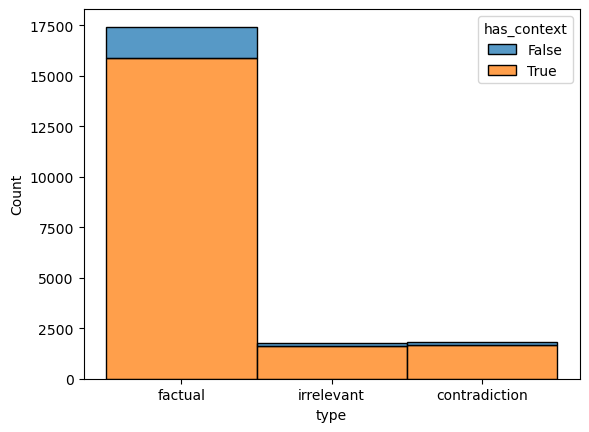

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train_df, x='type', hue='has_context', multiple='stack')
plt.show()

We observe that majority of the questions have context present, and belong to the factual category

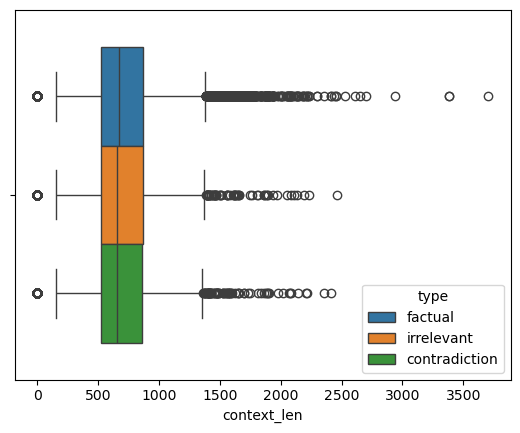

In [12]:
sns.boxplot(train_df,x='context_len', hue='type')
plt.show()

The context length distribution of the 3 types of answers are similar

In [13]:
# ! python -m spacy download en_core_web_md

In [14]:
import spacy
import nltk
import re
import string
# text preprocessing helper functions

def clean_text(text):
    '''Make text lowercase, remove punctuation'''
    text = text.lower()
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    return text


def text_preprocessing(text):
    """
    Cleaning and parsing the text.

    """
    tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
    nopunc = clean_text(text)
    tokenized_text = tokenizer.tokenize(nopunc)
    #remove_stopwords = [w for w in tokenized_text if w not in stopwords.words('english')]
    combined_text = ' '.join(tokenized_text)
    return combined_text

In [15]:
# Applying the cleaning function to training dataset
train_df['context_cleaned'] = train_df['context'].apply(str).apply(lambda x: text_preprocessing(x))

In [16]:
train_df['answer_cleaned'] = train_df['answer'].apply(str).apply(lambda x: text_preprocessing(x))
train_df['question_cleaned'] = train_df['question'].apply(str).apply(lambda x: text_preprocessing(x))

In [17]:
train_df['answer_word_count'] = train_df['answer_cleaned'].apply(lambda x: len(str(x).split()))

In [18]:
factual = train_df[train_df['type']=='factual']
irrelevant = train_df[train_df['type']=='irrelevant']
contradict = train_df[train_df['type']=='contradiction']

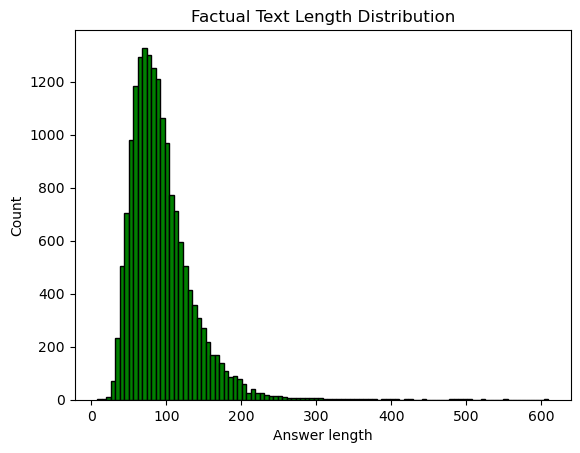

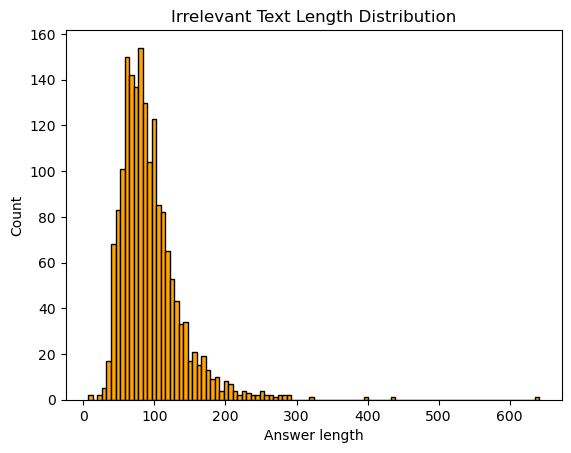

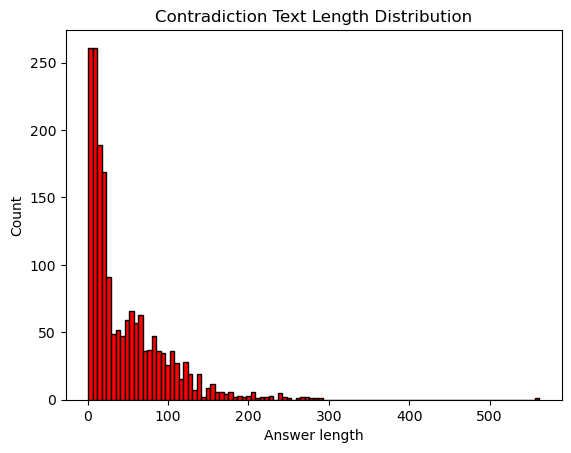

In [19]:
# Factual
plt.figure()
plt.hist(factual['answer_len'], bins=100, edgecolor='black', color='green')
plt.xlabel('Answer length')
plt.ylabel('Count')
plt.title('Factual Text Length Distribution')
plt.show()

# Irrelevant
plt.figure()
plt.hist(irrelevant['answer_len'], bins=100, edgecolor='black', color='orange')
plt.xlabel('Answer length')
plt.ylabel('Count')
plt.title('Irrelevant Text Length Distribution')
plt.show()

# Contradict
plt.figure()
plt.hist(contradict['answer_len'], bins=100, edgecolor='black', color='red')
plt.xlabel('Answer length')
plt.ylabel('Count')
plt.title('Contradiction Text Length Distribution')
plt.show()


We observe that factual and irrelevant answer types have similar distribution of answer lengths, with a peak of around 100 characters. While Contradictory answers clearly show a skewed distribution, peaking at 20 to 30 characters.

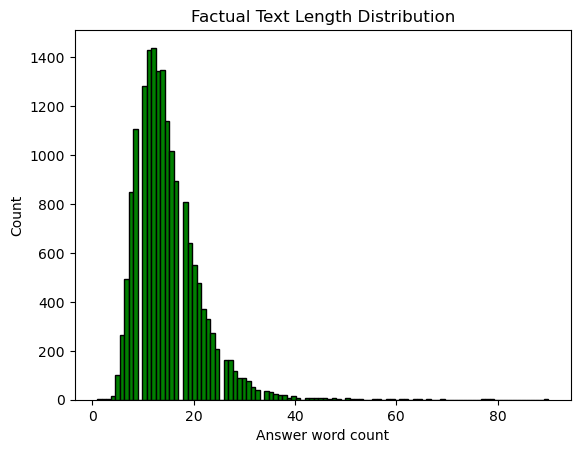

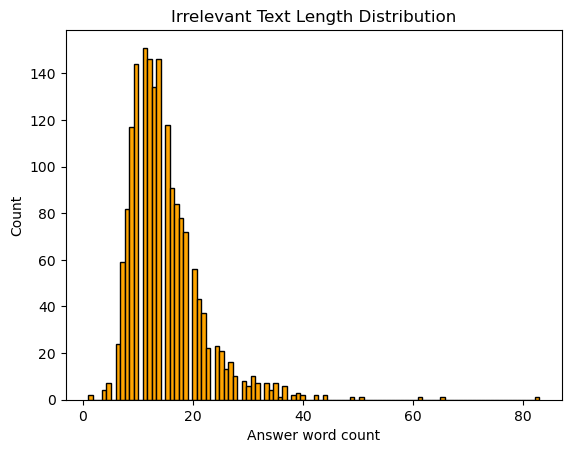

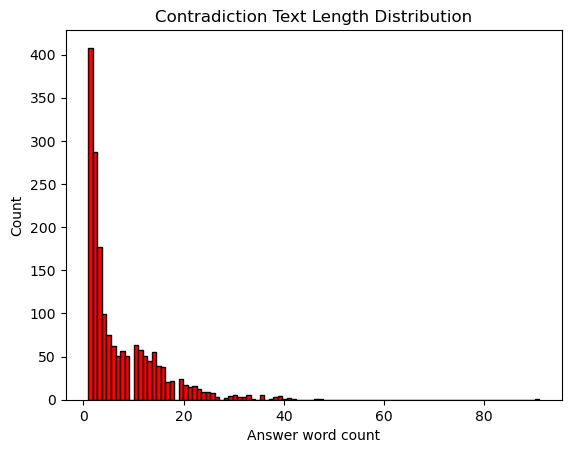

In [20]:
# Factual
plt.figure()
plt.hist(factual['answer_word_count'], bins=100, edgecolor='black', color='green')
plt.xlabel('Answer word count')
plt.ylabel('Count')
plt.title('Factual Text Length Distribution')
plt.show()

# Irrelevant
plt.figure()
plt.hist(irrelevant['answer_word_count'], bins=100, edgecolor='black', color='orange')
plt.xlabel('Answer word count')
plt.ylabel('Count')
plt.title('Irrelevant Text Length Distribution')
plt.show()

# Contradict
plt.figure()
plt.hist(contradict['answer_word_count'], bins=100, edgecolor='black', color='red')
plt.xlabel('Answer word count')
plt.ylabel('Count')
plt.title('Contradiction Text Length Distribution')
plt.show()

The word count shows a similar distribution 

In [21]:
train_df.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23


## BERT Similarity Score

BERT Similarity Score Uses BERT transformer model to assess sentence similarity by encoding two input sentences into fixed-size representations and then measuring the similarity between these representations. 

In [22]:
import transformers
print(transformers.__version__)

4.57.3


In [23]:
from transformers import BertTokenizer, BertModel
from bert_score import BERTScorer
# Example texts
reference = "This is a reference text example."
candidate = "This is a candidate text example."
# BERTScore calculation
scorer = BERTScorer(model_type='bert-base-uncased')
P, R, F1 = scorer.score([candidate], [reference])
print(f"BERTScore Precision: {P.mean():.4f}, Recall: {R.mean():.4f}, F1: {F1.mean():.4f}")

BERTScore Precision: 0.9258, Recall: 0.9258, F1: 0.9258


In [27]:
from bert_score import score

def compute_bertscore(df, answer_col='answer', context_col='context', lang='en', batch_size=32):
    answers = df[answer_col].tolist()
    contexts = df[context_col].tolist()

    all_precision, all_recall, all_f1 = [], [], []
    for i in range(0, len(answers), batch_size):
        batch_answers = answers[i:i+batch_size]
        batch_contexts = contexts[i:i+batch_size]

        P, R, F1 = score(cands=batch_answers, refs=batch_contexts, lang=lang, verbose=False)
        all_precision.extend(P.cpu().numpy())
        all_recall.extend(R.cpu().numpy())
        all_f1.extend(F1.cpu().numpy())

    df['bert_precision'] = all_precision
    df['bert_recall'] = all_recall
    df['bert_f1'] = all_f1

    return df


In [28]:
df_upd=compute_bertscore(train_df[:100], answer_col='answer', context_col='context', lang='en', batch_size=32)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\alejo\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alejo\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In [29]:
df_upd.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,bert_precision,bert_recall,bert_f1
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16,0.910652,0.820346,0.863143
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13,0.900042,0.803791,0.849198
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10,0.899771,0.822778,0.859554
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14,0.915695,0.831752,0.871707
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23,0.958196,0.866766,0.910191


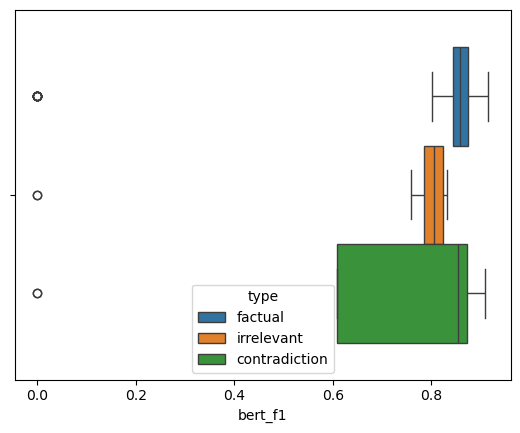

In [30]:
sns.boxplot(df_upd,x='bert_f1', hue='type')
plt.show()

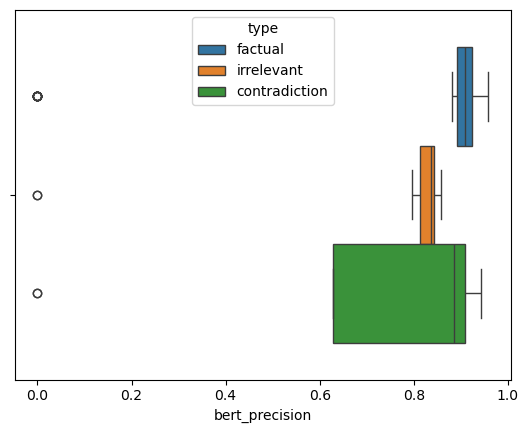

In [31]:
sns.boxplot(df_upd,x='bert_precision', hue='type')
plt.show()

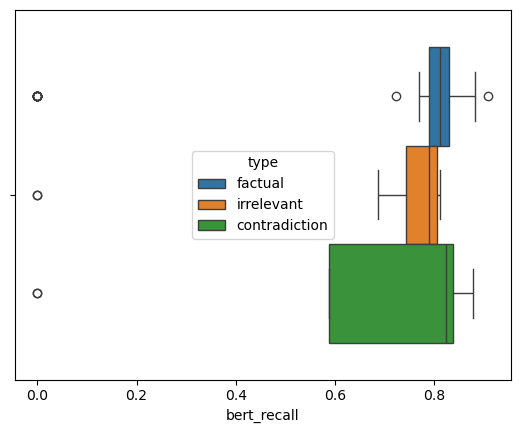

In [32]:
sns.boxplot(df_upd,x='bert_recall', hue='type')
plt.show()

- We see that factual responses have a much higher BERT Similarity Score (median around 0.9).
- Irrelevant responses have a smaller range of scores, around 0.8
- COntradictory responses have the widest range or variablitiy, from 0.6 to 0.9

## NLI Entailment Model

Natural Language Inference (NLI) is the task of deciding whether the given hypothesis logically follows from the premise. We use a pretrained BERT NLI model to determine the NLI score, indicating if the LLM answer is entailed from the given context, which would help in judging factuality.

In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Load the pretrained NLI model and tokenizer
model_name = "microsoft/deberta-base-mnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def get_entailment_score(premise, hypothesis):
    # Tokenize inputs (premise = context, hypothesis = answer)
    inputs = tokenizer.encode_plus(premise, hypothesis, return_tensors="pt", truncation=True)
    
    # Get model logits and convert to probabilities
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=1).squeeze()
    
    # The labels are [contradiction, neutral, entailment], so index 2 is entailment prob
    entailment_prob = probs[2].item()
    return entailment_prob

# Example use:
context = train_df.loc[0,'context']
answer = train_df.loc[0,'answer']

score = get_entailment_score(context, answer)
print(f"Entailment score (answer vs. context): {score:.4f}")


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Entailment score (answer vs. context): 0.9629


In [34]:
df_subset=train_df[:100]
df_subset['NLI Score']=df_subset.apply(lambda row: get_entailment_score(row['context'], row['answer']), axis=1)

C:\Users\alejo\AppData\Local\Temp\ipykernel_59640\3539362301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['NLI Score']=df_subset.apply(lambda row: get_entailment_score(row['context'], row['answer']), axis=1)


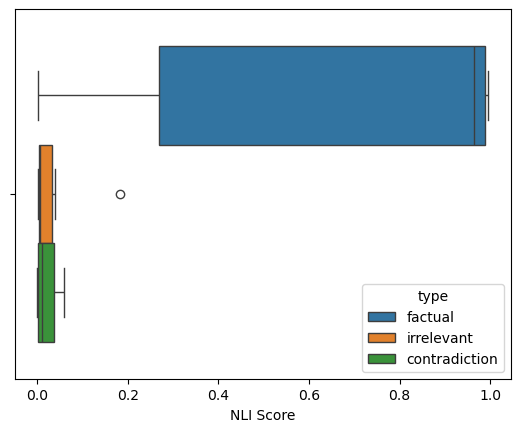

In [35]:
sns.boxplot(df_subset,x='NLI Score', hue='type')
plt.show()

In [ ]:

train_df['NLI Score']=train_df.apply(lambda row: get_entailment_score(row['context'], row['answer']), axis=1)

<Axes: xlabel='NLI Score'>

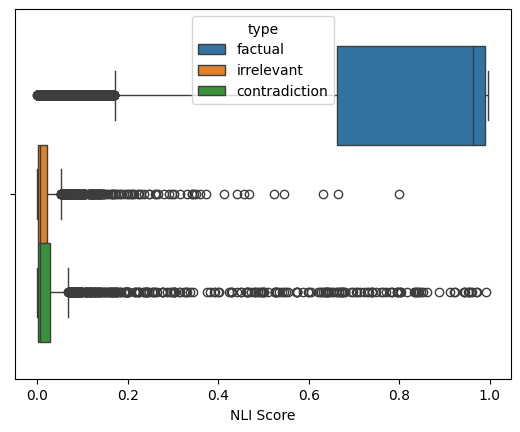

In [ ]:
sns.boxplot(train_df,x='NLI Score', hue='type')

- Clearly, we see that the responses with high NLI scores (above 0.7) are mostly factual responses. 
- Irrelevant and Contradictary responses are centered around low NLI scores (less than 0.1), with some outliers.
- Thus, NLI score can help distinguish factual from irrelevant and contradiction types.

In [ ]:
train_df.to_csv('train_with_bert_nli_scores.csv', index=False)

NLI entailment score for test dataset

In [25]:
test_df['NLI Score']=test_df.apply(lambda row: get_entailment_score(row['context'], row['answer']), axis=1)

## Evaluation using metrics and LLM Judge

In [ ]:
from dotenv import load_dotenv, find_dotenv
import os
import pandas as pd


In [3]:
dotenv_path = find_dotenv()
if dotenv_path:
    # Clear variables loaded by previous calls to load_dotenv, if necessary
    # (load_dotenv typically doesn't overwrite existing variables by default)
    # The following forces a reload and overwrite:
    load_dotenv(dotenv_path, override=True) 
    print("Environment variables reloaded.")
else:
    print(".env file not found.")

Environment variables reloaded.


In [3]:
train_data=pd.read_csv('train_with_bert_nli_scores.csv')

In [9]:
train_data.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,NLI Score
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16,0.962941
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13,0.856577
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10,0.963583
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14,0.933083
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23,0.995961


In [ ]:
train_data[train_data['context']==''].shape

(0, 13)

In [ ]:
train_data.shape

(21021, 13)

In [4]:
ENDPOINT = os.getenv('ENDPOINT_URL')
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
API_VERSION = "2024-12-01-preview"
DEPLOYMENT = "gpt-4o"  # Your deployment name

azure_configs = {
    "api_key": AZURE_OPENAI_API_KEY,
    "base_url": ENDPOINT,
    "model_deployment": DEPLOYMENT,
    "model_name": DEPLOYMENT,
    "api_version": API_VERSION,
}

In [5]:
from openai import AsyncOpenAI,  AsyncAzureOpenAI
from ragas.llms import llm_factory

azure_client = AsyncAzureOpenAI(
    api_key=azure_configs["api_key"],
    azure_endpoint=azure_configs["base_url"],
    api_version=azure_configs["api_version"],
)
llm = llm_factory(azure_configs["model_name"], client=azure_client)

/home/azureuser/.akshara_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.metrics.collections import Faithfulness



# Create metric
scorer = Faithfulness(llm=llm)

# Evaluate
result = await scorer.ascore(
    user_input="When was the first super bowl?",
    response="The first superbowl was held on Jan 15, 1967",
    retrieved_contexts=[
        "The First AFL–NFL World Championship Game was an American football game played on January 15, 1967, at the Los Angeles Memorial Coliseum in Los Angeles."
    ]
)
print(f"Faithfulness Score: {result.value}")

Faithfulness Score: 1.0


In [ ]:
from ragas import EvaluationDataset
train_data_upd=train_data.rename(columns={'context':'retrieved_contexts', 'answer':'response', 'question': 'user_input'})
train_data_upd["retrieved_contexts"] = train_data_upd["retrieved_contexts"].apply(
    lambda x: [] if pd.isna(x) else [x] 
)

dataset=train_data_upd[['retrieved_contexts','user_input','response']].to_dict(orient='records')


In [ ]:
len(dataset)

21021

In [7]:
from langchain_openai.chat_models import AzureChatOpenAI
from langchain_openai.embeddings import AzureOpenAIEmbeddings
from ragas import evaluate

azure_model = AzureChatOpenAI(
    openai_api_version=azure_configs["api_version"],
    azure_endpoint=azure_configs["base_url"],
    azure_deployment=azure_configs["model_deployment"],
    model=azure_configs["model_name"],
    validate_base_url=False,
)


Test on first 100 rows of train dataset

In [ ]:
evaluation_dataset = EvaluationDataset.from_list(dataset[:100])

In [ ]:
from ragas.metrics import LLMContextRecall, Faithfulness

result = evaluate(dataset=evaluation_dataset,metrics=[Faithfulness()],llm=azure_model)


/tmp/ipykernel_97744/3971391328.py:1: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextRecall
  from ragas.metrics import LLMContextRecall, Faithfulness
/tmp/ipykernel_97744/3971391328.py:1: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import LLMContextRecall, Faithfulness
Evaluating: 100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


In [ ]:
result

{'faithfulness': 0.6192}

In [ ]:
type(result)

ragas.dataset_schema.EvaluationResult

In [ ]:
per_row_scores = result.to_pandas()
per_row_scores.head()

,user_input,retrieved_contexts,response,faithfulness
0,In what year did Parliament pass a notable law...,[During the Hundred Years' War a French attack...,"In 1512, Parliament passed a significant act t...",1.0
1,Who established early settlements in Florida,"[""By May 1539, Conquistador Hernando de Soto s...",The Spanish and French were the ones who estab...,1.0
2,When do monsoons traditionally happen in Punjab?,[The onset of the southwest monsoon is anticip...,"Traditionally, monsoons in Punjab are expected...",0.5
3,Who made the requests for Kondo to use orchest...,[Media requests at the trade show prompted Kon...,The media made the requests for Kondo to use o...,0.0
4,How many inventors came up with electric lamps...,[In addressing the question of who invented th...,According to historians Robert Friedel and Pau...,1.0


In [ ]:
analyse_res=pd.concat([train_data[:100],per_row_scores], axis=1)
analyse_res.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,NLI Score,user_input,retrieved_contexts,response,faithfulness
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16,0.962941,In what year did Parliament pass a notable law...,[During the Hundred Years' War a French attack...,"In 1512, Parliament passed a significant act t...",1.0
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13,0.856577,Who established early settlements in Florida,"[""By May 1539, Conquistador Hernando de Soto s...",The Spanish and French were the ones who estab...,1.0
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10,0.963583,When do monsoons traditionally happen in Punjab?,[The onset of the southwest monsoon is anticip...,"Traditionally, monsoons in Punjab are expected...",0.5
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14,0.933083,Who made the requests for Kondo to use orchest...,[Media requests at the trade show prompted Kon...,The media made the requests for Kondo to use o...,0.0
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23,0.995961,How many inventors came up with electric lamps...,[In addressing the question of who invented th...,According to historians Robert Friedel and Pau...,1.0


<Axes: xlabel='faithfulness'>

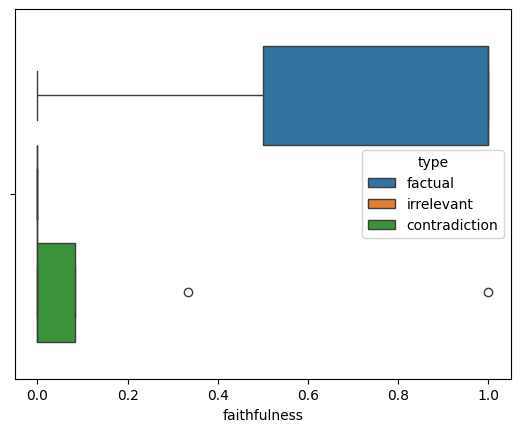

In [ ]:
import seaborn as sns
sns.boxplot(analyse_res,x='faithfulness', hue='type')


In [ ]:
analyse_res['faithfulness'].describe()

count    100.000000
mean       0.619167
std        0.460910
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: faithfulness, dtype: float64

In [ ]:
len(dataset)

21021

### Faithfulness score on first half of train dataset

We use the RAGAS faithfulness metric, which is defined as below:

The Faithfulness metric measures how factually consistent a response is with the retrieved context. It ranges from 0 to 1, with higher scores indicating better consistency.

A response is considered faithful if all its claims can be supported by the retrieved context.



In [ ]:
from ragas.metrics import LLMContextRecall, Faithfulness

# Execute evaluation in batches
batch_size = 200
all_results = []
result_total=pd.DataFrame()
for i in range(0, len(dataset[:10000]), batch_size):
    batch_dataset = EvaluationDataset.from_list(dataset[i:i+batch_size])
    batch_result = evaluate(dataset=batch_dataset, metrics=[Faithfulness()], llm=azure_model)
    result_df=batch_result.to_pandas()
    result_total = pd.concat([result_total, result_df], ignore_index=True)

result_total.to_csv('faithfulness_scores_1.csv', index=False)

In [ ]:
result_total.shape

(10000, 4)

In [ ]:
res_df=pd.concat([train_data[:10000],result_total], axis=1)

In [ ]:
res_df.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,NLI Score,user_input,retrieved_contexts,response,faithfulness
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16,0.962941,In what year did Parliament pass a notable law...,[During the Hundred Years' War a French attack...,"In 1512, Parliament passed a significant act t...",1.0
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13,0.856577,Who established early settlements in Florida,"[""By May 1539, Conquistador Hernando de Soto s...",The Spanish and French were the ones who estab...,1.0
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10,0.963583,When do monsoons traditionally happen in Punjab?,[The onset of the southwest monsoon is anticip...,"Traditionally, monsoons in Punjab are expected...",0.5
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14,0.933083,Who made the requests for Kondo to use orchest...,[Media requests at the trade show prompted Kon...,The media made the requests for Kondo to use o...,0.0
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23,0.995961,How many inventors came up with electric lamps...,[In addressing the question of who invented th...,According to historians Robert Friedel and Pau...,1.0


<Axes: xlabel='faithfulness'>

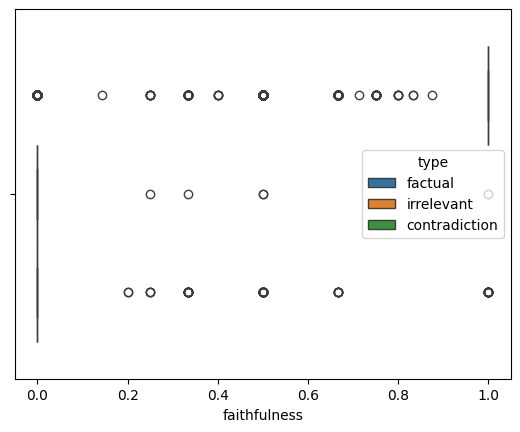

In [ ]:
sns.boxplot(res_df,x='faithfulness', hue='type')

In [ ]:
res_df.groupby('type')['faithfulness'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
contradiction,919.0,0.053119,0.184935,0.0,0.0,0.0,0.0,1.0
factual,8215.0,0.841990,0.339854,0.0,1.0,1.0,1.0,1.0
irrelevant,860.0,0.004167,0.055634,0.0,0.0,0.0,0.0,1.0


### Faithfulness evaluation on second half of dataset

In [ ]:
# Execute evaluation in batches
batch_size = 200
all_results = []
result_total=pd.DataFrame()
for i in range(10000, len(dataset), batch_size):
    batch_dataset = EvaluationDataset.from_list(dataset[i:i+batch_size])
    batch_result = evaluate(dataset=batch_dataset, metrics=[Faithfulness()], llm=azure_model)
    result_df=batch_result.to_pandas()
    result_total = pd.concat([result_total, result_df], ignore_index=True)

result_total.to_csv('faithfulness_scores_2.csv', index=False)

Evaluating:  44%|████▍     | 88/200 [01:12<01:50,  1.01it/s]Exception raised in Job[94]: OutputParserException(Invalid json output: The input question and answer do not align. The question asks about water tariffs and water treatment operations, while the answer discusses Henry III and the rebuilding of an abbey. This mismatch makes it impossible to generate meaningful statements based on the provided schema. Please provide a corrected input where the question and answer are related.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE )
Evaluating:  60%|██████    | 121/200 [01:30<00:39,  1.99it/s]Exception raised in Job[117]: OutputParserException(Invalid json output: The input question and answer do not align correctly. The question asks about Polish-Lithuanian monarchs after 1573, but the answer discusses the Canadian Armed Forces during the Cold War. This mismatch makes it impossible to generate meaningful statements based on the

In [ ]:
result_total.shape

(11021, 4)

In [ ]:
result_total.head(10)

,user_input,retrieved_contexts,response,faithfulness
0,Name a compond that can mobilize sold copper?,[Chromobacterium violaceum and Pseudomonas flu...,One compound that can mobilize solid copper is...,0.0
1,What is the largest hill in Paris?,[Paris is located in northern central France. ...,"The largest hill in Paris is Montmartre, which...",1.0
2,What territory did Yugoslavia leadership want ...,"[In the immediate aftermath of World War II, t...",Yugoslav leadership sought to incorporate the ...,1.0
3,On what date was Little Boy detonated?,[Two major types of atomic bombs were develope...,9 August 1945,0.0
4,Who has established herself as a Queen of Popu...,[Madonna's music has been the subject of much ...,Madonna has established herself as the Queen o...,1.0
5,How many groups of the Directorate of Analysis...,[The Directorate of Analysis produces all-sour...,Modified answer (with contradiction): seven,0.0
6,Who was the founder of Hasidic Judaism?,[Pantheism holds that God is the universe and ...,Kanye West drew inspiration from the melody an...,0.0
7,What did the Movement question?,"[During this period, Bengal witnessed an intel...","The movement questioned existing orthodoxies, ...",1.0
8,When did the Roman Republic begin?,[],The Roman Republic began in 509 BC.,0.0
9,What percentage of the Nicaraguan population a...,[],Approximately 5% of Nicaragua's population is ...,0.0


In [ ]:
train_data[10000:].head(10)

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,NLI Score
10000,One compound that can mobilize solid copper is...,factual,Chromobacterium violaceum and Pseudomonas fluo...,Name a compond that can mobilize sold copper?,True,567,45,73,chromobacterium violaceum and pseudomonas fluo...,one compound that can mobilize solid copper is...,name a compond that can mobilize sold copper,10,0.988782
10001,"The largest hill in Paris is Montmartre, which...",factual,Paris is located in northern central France. B...,What is the largest hill in Paris?,True,1010,34,105,paris is located in northern central france by...,the largest hill in paris is montmartre which ...,what is the largest hill in paris,19,0.981089
10002,Yugoslav leadership sought to incorporate the ...,factual,"In the immediate aftermath of World War II, th...",What territory did Yugoslavia leadership want ...,True,1405,61,81,in the immediate aftermath of world war ii the...,yugoslav leadership sought to incorporate the ...,what territory did yugoslavia leadership want ...,12,0.974744
10003,9 August 1945,contradiction,Two major types of atomic bombs were developed...,On what date was Little Boy detonated?,True,916,38,13,two major types of atomic bombs were developed...,9 august 1945,on what date was little boy detonated,3,0.001843
10004,Madonna has established herself as the Queen o...,factual,Madonna's music has been the subject of much a...,Who has established herself as a Queen of Popu...,True,1187,56,62,madonnas music has been the subject of much an...,madonna has established herself as the queen o...,who has established herself as a queen of popu...,10,0.964451
10005,Modified answer (with contradiction): seven,contradiction,The Directorate of Analysis produces all-sourc...,How many groups of the Directorate of Analysis...,True,593,93,43,the directorate of analysis produces allsource...,modified answer with contradiction seven,how many groups of the directorate of analysis...,5,0.024804
10006,Kanye West drew inspiration from the melody an...,irrelevant,Pantheism holds that God is the universe and t...,Who was the founder of Hasidic Judaism?,True,739,39,133,pantheism holds that god is the universe and t...,kanye west drew inspiration from the melody an...,who was the founder of hasidic judaism,22,0.018409
10007,"The movement questioned existing orthodoxies, ...",factual,"During this period, Bengal witnessed an intell...",What did the Movement question?,True,705,31,139,during this period bengal witnessed an intelle...,the movement questioned existing orthodoxies p...,what did the movement question,19,0.903639
10008,The Roman Republic began in 509 BC.,factual,NaN,When did the Roman Republic begin?,False,0,34,35,NaN,the roman republic began in 509 bc,when did the roman republic begin,7,0.001237
10009,Approximately 5% of Nicaragua's population is ...,factual,NaN,What percentage of the Nicaraguan population a...,False,0,60,57,NaN,approximately 5 of nicaraguas population is in...,what percentage of the nicaraguan population a...,7,0.002617


Combine the results into single file

In [ ]:
import pandas as pd
res_1=pd.read_csv('faithfulness_scores_1.csv')
res_2=pd.read_csv('faithfulness_scores_2.csv')
res_df_full=pd.concat([res_1,res_2], ignore_index=True)
res_df_full.shape

(21021, 4)

In [ ]:
train_data.shape

(21021, 13)

In [ ]:
result_combined=pd.concat([train_data,res_df_full['faithfulness']], axis=1)

In [ ]:
result_combined.head()

,answer,type,context,question,has_context,context_len,question_len,answer_len,context_cleaned,answer_cleaned,question_cleaned,answer_word_count,NLI Score,faithfulness
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...,True,1135,102,109,during the hundred years war a french attack 1...,in 1512 parliament passed a significant act th...,in what year did parliament pass a notable law...,16,0.962941,1.0
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida,True,887,45,82,by may 1539 conquistador hernando de soto skir...,the spanish and french were the ones who estab...,who established early settlements in florida,13,0.856577,1.0
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?,True,798,48,63,the onset of the southwest monsoon is anticipa...,traditionally monsoons in punjab are expected ...,when do monsoons traditionally happen in punjab,10,0.963583,0.5
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...,True,686,76,82,media requests at the trade show prompted kond...,the media made the requests for kondo to use o...,who made the requests for kondo to use orchest...,14,0.933083,0.0
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...,True,511,68,152,in addressing the question of who invented the...,according to historians robert friedel and pau...,how many inventors came up with electric lamps...,23,0.995961,1.0


In [ ]:
result_combined.shape

(21021, 14)

Record Faithfulness scores for test dataset

In [32]:
test_data_upd=test_df.rename(columns={'context':'retrieved_contexts', 'answer':'response', 'question': 'user_input'})
test_data_upd["retrieved_contexts"] = test_data_upd["retrieved_contexts"].apply(
    lambda x: [] if pd.isna(x) else [x] 
)

dataset=test_data_upd[['retrieved_contexts','user_input','response']].to_dict(orient='records')


In [34]:
from ragas import EvaluationDataset
from ragas.metrics import LLMContextRecall, Faithfulness

test_dataset = EvaluationDataset.from_list(dataset)
result = evaluate(dataset=test_dataset, metrics=[Faithfulness()], llm=azure_model)
result_df=result.to_pandas()
test_data_with_scores=pd.concat([test_df,result_df['faithfulness']], axis=1)
test_data_with_scores.to_csv('test_data_with_faithfulness_scores.csv', index=False)

Evaluating:  19%|█▉        | 388/2000 [05:10<19:01,  1.41it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x776a71d45300> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-6959' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/azureuser/.akshara_venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-6961' coro=<Kernel.shell_main() running at /home/azureuser/.akshara_venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/azureuser/.akshara_venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending nam

#### Analysis of Faithfulness scores

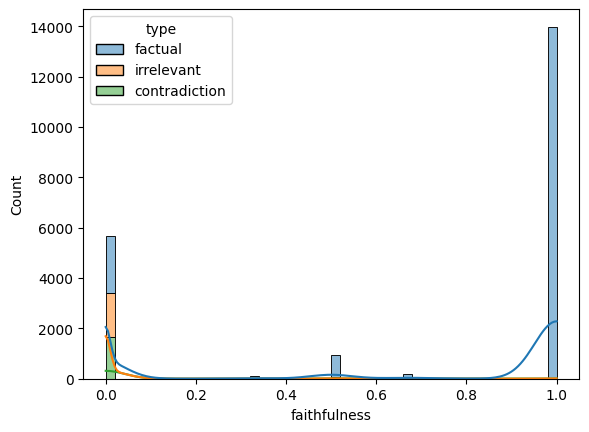

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(result_combined, x='faithfulness', hue='type', kde=True, multiple='stack', bins=50)
plt.show()

In [ ]:
result_combined.groupby('type')['faithfulness'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
contradiction,1818.0,0.053104,0.190188,0.0,0.0,0.0,0.0,1.0
factual,17422.0,0.837194,0.345415,0.0,1.0,1.0,1.0,1.0
irrelevant,1765.0,0.002597,0.045561,0.0,0.0,0.0,0.0,1.0


In [ ]:
result_combined.groupby('type')[['faithfulness', 'NLI Score']].describe()

faithfulness                                               \
                     count      mean       std  min  25%  50%  75%  max   
type                                                                      
contradiction       1818.0  0.053104  0.190188  0.0  0.0  0.0  0.0  1.0   
factual            17422.0  0.837194  0.345415  0.0  1.0  1.0  1.0  1.0   
irrelevant          1765.0  0.002597  0.045561  0.0  0.0  0.0  0.0  1.0   

              NLI Score                                                    \
                  count      mean       std       min       25%       50%   
type                                                                        
contradiction    1818.0  0.066420  0.171604  0.000031  0.000908  0.005013   
factual         17431.0  0.756647  0.356155  0.000104  0.661700  0.964397   
irrelevant       1772.0  0.025589  0.058294  0.000093  0.002196  0.006338   

                                   
                    75%       max  
type                               
contradiction  0.027538  0.992448  
factual        0.989112  0.997341  
irrelevant     0.021878  0.800437

In [ ]:
result_combined.to_csv('train_with_faithfulness_scores.csv', index=False)

## Analysis of Metrics for Classification

In [35]:
import pandas as pd
data_scores=pd.read_csv('train_with_faithfulness_scores.csv')

In [36]:
data_scores['type_encoded']=data_scores['type'].map({'factual':0, 'irrelevant':1, 'contradiction':2})

In [37]:
data_scores_num=data_scores.select_dtypes(include=['float64', 'int64'])

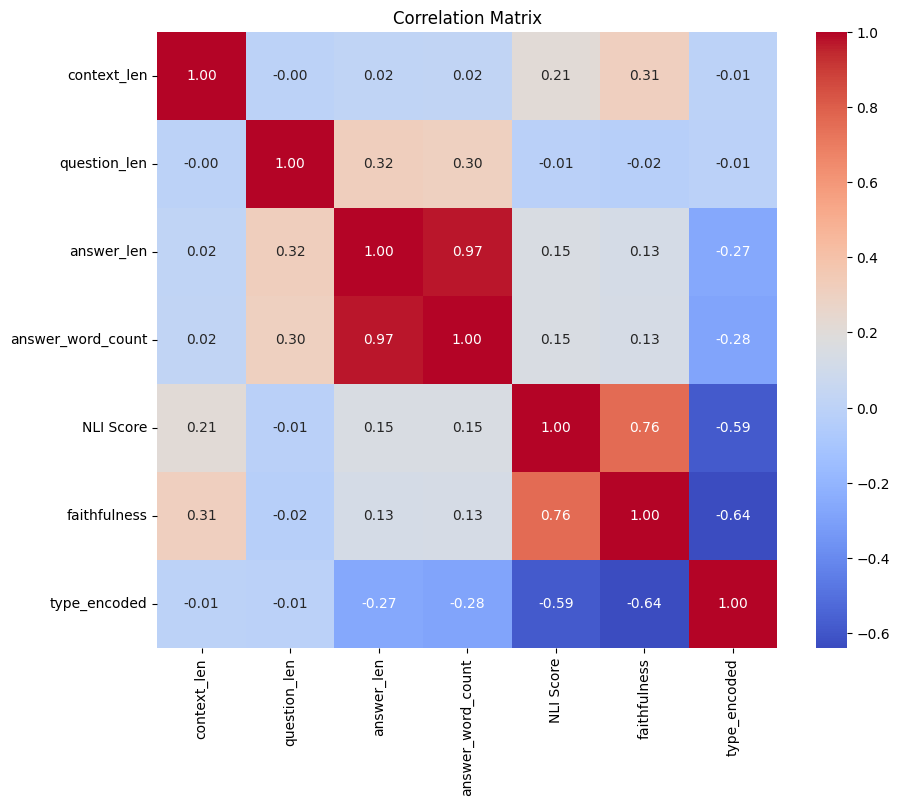

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

corr=data_scores_num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

Observations from Correlation Matrix:
- Context Length has slight positive correlation with faithfulness and NLI scores
- NLI score and faithfulness have high positive correlation
- The type of response is significantly correlated with NLI score and faithfulness
- The type of response has slight correlation with answer length

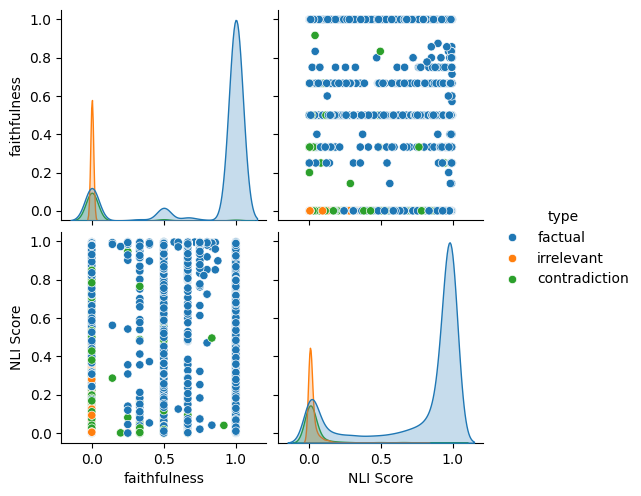

In [42]:
sns.pairplot(data_scores, vars=["faithfulness", "NLI Score"], hue="type")
plt.show()


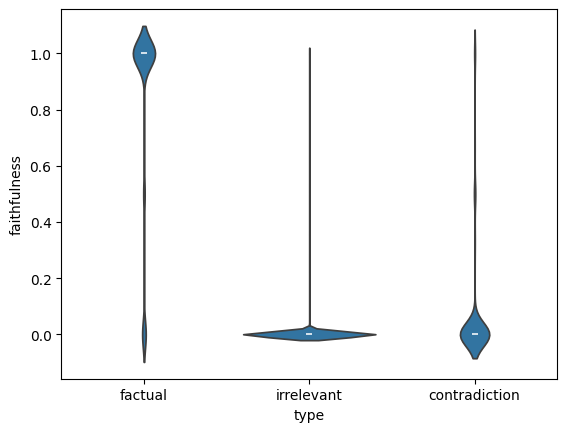

In [43]:
sns.violinplot(data=data_scores, x="type", y="faithfulness")
plt.show()


The above violinplot shows the distribution of faithfulness scores based on response type
- We observe that most factual responses have very high faithfulness scores, centered around 1, with a few outliers.
- Irrelevant responses have least range of faithfulness scores, with a mean close to 0.
- The contradiction responses have a wider range of faithfulness, mostly below 0.1.

## LLM Judge

In [ ]:
import pandas as pd
from openai import AzureOpenAI
from typing import List, Dict, Optional
import time


class LLMJudge:
    def __init__(self, endpoint: str, api_key: str, api_version: str, deployment: str):
        """
        Initialize the LLM Judge with Azure OpenAI endpoint
        
        Args:
            endpoint: Azure OpenAI endpoint URL
            api_key: API key for authentication
            api_version: API version (e.g., "2024-02-15-preview")
            deployment: Model deployment name
        """
        self.endpoint = endpoint
        self.api_key = api_key
        self.api_version = api_version
        self.deployment = deployment
        
        self.client = AzureOpenAI(
            api_version=api_version,
            azure_endpoint=endpoint,
            api_key=api_key,
        )
    
    def create_judge_prompt(self, question: str, context: str, answer: str, 
                           nli_score: Optional[float] = None, faithfulness: Optional[float] = None) -> str:
        """Create the prompt for the LLM judge"""
        
        nli_info = ""
        if nli_score is not None:
            nli_info = f"""
        NLI Entailment Score (context → answer): {nli_score:.3f}
        (0 = strong contradiction, 0.5 = neutral, 1 = strong entailment)

        """
        if faithfulness is not None:
            faithfulness_info=f"""
        Faithfulness Score (0 to 1): {faithfulness:.3f}
        It measures how factually consistent a response is with the retrieved context
        (0: completely unrelated or contradictory answer, 1: fully faithful answer)
                    """
        prompt = f"""You are an expert evaluator tasked with classifying LLM responses based on their relationship to the question and reference context, if present.

        Question: {question}

        Reference Context: {context}

        LLM Answer: {answer}

        {nli_info}

        {faithfulness_info}

        Classify this answer into exactly ONE of these categories:

        1. **FACTUAL**: The answer correctly addresses the question AND the core information is accurate and supported by the reference context (or general knowledge if no context). Minor wording differences or missing details do NOT make an answer non-factual if the essential meaning is correct.

        2. **IRRELEVANT**: The answer does NOT address the question asked. It may discuss tangentially related topics or be completely off-topic, regardless of whether the information itself is accurate.

        3. **CONTRADICTION**: The answer attempts to address the question BUT provides information that is CLEARLY AND DEMONSTRABLY WRONG - either directly contradicting specific facts in the reference context or containing major factual errors. Use this category ONLY when the answer contains obvious falsehoods, not for minor imprecisions or alternative phrasings.

        **Evaluation Process:**

        Step 1 - Relevance Check:
        - Does the answer address the specific question asked?
        - If NO → Classify as IRRELEVANT
        - If YES → Proceed to Step 2

        Step 2 - Factual Accuracy Check ( FOCUS ON CORE CORRECTNESS):
        - **CRITICAL**: Focus on whether the CORE CLAIM in the answer is correct, not minor details
        - Compare the answer's main point with the reference context
        - If context is provided:
        * Is the answer supported by the essential information in the context, even if worded differently?
        * High NLI (>0.8) suggests strong alignment - lean toward FACTUAL
        * Only classify as CONTRADICTION if the answer makes claims that are EXPLICITLY contradicted by the context
        - If no context is provided:
        * Is the answer's main claim factually correct based on general knowledge?
        * Low metrics alone don't mean CONTRADICTION - verify the actual claim is wrong
        - Ask yourself: "Is the answer's core claim actually FALSE, or is it just imprecisely worded?"
        * If the core claim is TRUE → FACTUAL
        * If the core claim is FALSE → CONTRADICTION
        
        **Examples to Guide Classification:**
        Example 1:
        Q: “What caused the citywide blackout?”
        Context: “Officials reported that a failed transformer led to a cascading power outage across the city.”
        Answer: “The blackout happened because a transformer failure caused widespread power loss.”
        → FACTUAL (Core cause—transformer failure—is correctly preserved without distortion.)

        Example 2:
        Q: “How long did the expedition last?”
        Context: “The expedition lasted just over three months, ending in early September.”
        Answer: “The expedition lasted about six months before it ended.”
        → CONTRADICTION ((Duration is substantially incorrect and conflicts with the context.))

        Example 3:
        Q: "What color is the sky?"
        Context: "The atmosphere scatters blue light..."
        Answer: "Elephants are large mammals with trunks."
        → IRRELEVANT (Doesn't address the question at all)

        Example 4:
        Q: “Why was the policy delayed?”
        Context: “The policy was delayed due to ongoing negotiations between the two parties.”
        Answer: “The policy was delayed because negotiations were still ongoing.”
        → FACTUAL (The answer restates the same causal reason with equivalent wording.)

        **Important Guidelines:**
        - Default to FACTUAL if the answer is substantially correct, even if it does not cover all points in the context
        - Be lenient with paraphrasing - focus on whether the meaning is preserved
        - Partial but correct answers should be classified as FACTUAL
        - Vague or generic answers that don't specifically address the question are IRRELEVANT
        - If the answer says "I don't know" or refuses to answer, classify as IRRELEVANT
        - When in doubt between FACTUAL and CONTRADICTION, ask: "Would this answer actually mislead someone?" If no, choose FACTUAL

        **Required Output Format:**
        CATEGORY: [FACTUAL/IRRELEVANT/CONTRADICTION]
        CONFIDENCE: [0.0-1.0] (Your confidence level in this classification)
        JUSTIFICATION: [Brief explanation of your classification in 1-2 sentences]"""
                
        return prompt
    
    def call_llm(self, prompt: str, retry_count: int = 3) -> str:
        """Call the Azure OpenAI endpoint with retry logic"""
        for attempt in range(retry_count):
            try:
                response = self.client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a precise evaluator. Always respond in the exact format requested."
                        },
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    max_completion_tokens=200,
                    # temperature=0.1,
                    model=self.deployment
                )
                
                return response.choices[0].message.content
            
            except Exception as e:
                print(f"Attempt {attempt + 1}/{retry_count} failed: {e}")
                if attempt < retry_count - 1:
                    time.sleep(2 ** attempt)  # Exponential backoff
                else:
                    print(f"All retry attempts failed. Error: {e}")
                    return None
    
    def parse_judgment(self, response: str) -> Dict[str, str]:
        """Parse the LLM's judgment response"""
        lines = response.strip().split('\n')
        category = None
        justification = None
        
        for line in lines:
            if line.startswith('CATEGORY:'):
                category = line.replace('CATEGORY:', '').strip().upper()
            elif line.startswith('JUSTIFICATION:'):
                justification = line.replace('JUSTIFICATION:', '').strip()
            elif line.startswith('CONFIDENCE:'):
                confidence = line.replace('CONFIDENCE:', '').strip()
        
        # Validate category
        if category not in ['FACTUAL', 'IRRELEVANT', 'CONTRADICTION']:
            category = 'UNKNOWN'
        
        return {
            'category': category,
            'confidence': confidence or None,
            'justification': justification or 'No justification provided'
        }
    
    def evaluate_single(self, question: str, context: str, answer: str, 
                       nli_score: Optional[float] = None, faithfulness: Optional[float] = None) -> Dict[str, str]:
        """Evaluate a single LLM response"""
        prompt = self.create_judge_prompt(question, context, answer, nli_score, faithfulness)
        response = self.call_llm(prompt)
        
        if response:
            return self.parse_judgment(response)
        else:
            return {
                'category': 'ERROR', 
                'confidence': None,
                'justification': 'Failed to get LLM response after retries'
            }
    
    def evaluate_dataframe(self, df: pd.DataFrame, 
                          question_col: str = 'question',
                          context_col: str = 'context',
                          answer_col: str = 'answer',
                          nli_score_col: Optional[str] = 'NLI Score',
                          faithfulness_col: Optional[str] = 'faithfulness',
                          delay: float = 0.5) -> pd.DataFrame:
        """
        Evaluate all rows in a dataframe
        
        Args:
            df: DataFrame with questions, contexts, and answers
            question_col: Name of the question column
            context_col: Name of the context column
            answer_col: Name of the answer column
            nli_score_col: Name of the NLI score column (optional, set to None if not available)
            delay: Delay between API calls (seconds)
        
        Returns:
            DataFrame with added judgment columns
        """
        results = []
        
        for idx, row in df.iterrows():
            # print(f"Evaluating row {idx + 1}/{len(df)}...")
            
            
            judgment = self.evaluate_single(
                question=row[question_col],
                context=row[context_col],
                answer=row[answer_col],
                nli_score=row[nli_score_col],
                faithfulness=row[faithfulness_col]
            )
            
            results.append(judgment)
            
            # Rate limiting
            if idx < len(df) - 1:
                time.sleep(delay)
        
        # Add results to dataframe
        df['judgment_category'] = [r['category'] for r in results]
        df['judgment_justification'] = [r['justification'] for r in results]
        df['judgement_confidence'] = [r['confidence'] for r in results]
        return df
    
    def print_summary(self, df: pd.DataFrame):
        """Print summary statistics of judgments"""
        print("\n" + "="*60)
        print("EVALUATION SUMMARY")
        print("="*60)
        
        category_counts = df['judgment_category'].value_counts()
        
        for category, count in category_counts.items():
            percentage = (count / len(df)) * 100
            print(f"{category}: {count} ({percentage:.1f}%)")
        
        print("="*60 + "\n")


Testing the LLM as a judge on the first 1000 rows of training set

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Configuration 
ENDPOINT = os.getenv('ENDPOINT_URL')
API_KEY = os.getenv('API_KEY_AZURE')
API_VERSION = "2024-12-01-preview"
DEPLOYMENT = "gpt-4o"  # Your deployment name

train_data=pd.read_csv('train_with_faithfulness_scores.csv')
test_df=train_data.loc[:, ['question','context','answer', 'NLI Score', 'faithfulness']]
actual_categories = train_data.loc[:, 'type']
    # Initialize judge
judge = LLMJudge(
    endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    deployment=DEPLOYMENT
)

batch_size = 200
result_total=pd.DataFrame()
for i in range(0, 1000, batch_size):
    batch_dataset = train_data[i:i+batch_size]
        # Evaluate
    df_evaluated = judge.evaluate_dataframe(batch_dataset)
    
    
    actual_res=actual_categories[i:i+batch_size]
    df_evaluated['actual_category']=actual_res.values
    result_total = pd.concat([result_total, df_evaluated], ignore_index=True)
    # Display results
    print(f"\nEVALUATION RESULTS for rows {i}:{i+batch_size}:")
    # print(df_evaluated[['question', 'answer', 'judgment_category']].to_string(index=False))
    # Print summary
    judge.print_summary(df_evaluated)


result_total.to_csv('llm_judge_evaluation_results_part_1.csv', index=False)

    
    


EVALUATION RESULTS for rows 0:200:

EVALUATION SUMMARY
FACTUAL: 134 (67.0%)
CONTRADICTION: 36 (18.0%)
IRRELEVANT: 30 (15.0%)


EVALUATION RESULTS for rows 200:400:

EVALUATION SUMMARY
FACTUAL: 155 (77.5%)
CONTRADICTION: 25 (12.5%)
IRRELEVANT: 20 (10.0%)


EVALUATION RESULTS for rows 400:600:

EVALUATION SUMMARY
FACTUAL: 147 (73.5%)
CONTRADICTION: 33 (16.5%)
IRRELEVANT: 20 (10.0%)



In [1]:
import pandas as pd
result_1=pd.read_csv('llm_judge_evaluation_results_part_1.csv')


In [4]:
print(f"Total samples evaluated: {len(result_1)}")
#Find accuracy of the judgements
correct_count = sum(result_1['judgment_category'].str.lower() == result_1['actual_category'].str.lower())
total_count = len(result_1['actual_category'])
accuracy = correct_count / total_count * 100
print(f"Accuracy of judgments: {accuracy:.2f}%")
#Per class accuracy
for category in ['factual', 'irrelevant', 'contradiction']:
    category_mask = result_1['actual_category'].str.lower() == category
    correct_in_category = sum((result_1['judgment_category'].str.lower() == result_1['actual_category'].str.lower()) & category_mask)
    total_in_category = sum(category_mask)
    if total_in_category > 0:
        category_accuracy = correct_in_category / total_in_category * 100
        print(f"Accuracy for {category.capitalize()}: {category_accuracy:.2f}%")
    else:
        print(f"No samples for category {category.capitalize()}")

Total samples evaluated: 1000
Accuracy of judgments: 91.50%
Accuracy for Factual: 89.89%
Accuracy for Irrelevant: 100.00%
Accuracy for Contradiction: 96.97%


In [6]:
import warnings
warnings.filterwarnings('ignore')

# Configuration 
ENDPOINT = os.getenv('ENDPOINT_URL')
API_KEY = os.getenv('API_KEY_AZURE')
API_VERSION = "2024-12-01-preview"
DEPLOYMENT = "gpt-4o"  # Your deployment name

train_data=pd.read_csv('train_with_faithfulness_scores.csv')
test_df=train_data.loc[:, ['question','context','answer', 'NLI Score', 'faithfulness']]
actual_categories = train_data.loc[:, 'type']
    # Initialize judge
judge = LLMJudge(
    endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    deployment=DEPLOYMENT
)
batch_size = 500
result_total=pd.DataFrame()
for i in range(1000, 10000, batch_size):
    batch_dataset = train_data[i:i+batch_size]
    # Evaluate
    df_evaluated = judge.evaluate_dataframe(batch_dataset)
    
    actual_res=actual_categories[i:i+batch_size]
    df_evaluated['actual_category']=actual_res.values
    result_total = pd.concat([result_total, df_evaluated], ignore_index=True)
    # Display results
    print(f"\nEVALUATION RESULTS for rows {i}:{i+batch_size}:")
    # Print summary
    judge.print_summary(df_evaluated)

result_total.to_csv('llm_judge_evaluation_results_part_2.csv', index=False)

Attempt 1/3 failed: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': True, 'severity': 'medium'}}}}}
Attempt 2/3 failed: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please r

In [1]:
import pandas as pd
res_1=pd.read_csv('llm_judge_evaluation_results_part_1.csv')
res_2=pd.read_csv('llm_judge_evaluation_results_part_2.csv')

In [2]:
results_train_1=pd.concat([res_1,res_2], ignore_index=True)

### Evaluation and Analysis of Results - Iteration 1

In [3]:

print(f"Total samples evaluated: {len(results_train_1)}")
#Find accuracy of the judgements
correct_count = sum(results_train_1['judgment_category'].str.lower() == results_train_1['actual_category'].str.lower())
total_count = len(results_train_1['actual_category'])
accuracy = correct_count / total_count * 100
print(f"Accuracy of judgments: {accuracy:.2f}%")
#Per class accuracy
for category in ['factual', 'irrelevant', 'contradiction']:
    category_mask = results_train_1['actual_category'].str.lower() == category
    correct_in_category = sum((results_train_1['judgment_category'].str.lower() == results_train_1['actual_category'].str.lower()) & category_mask)
    total_in_category = sum(category_mask)
    if total_in_category > 0:
        category_accuracy = correct_in_category / total_in_category * 100
        print(f"Accuracy for {category.capitalize()}: {category_accuracy:.2f}%")
    else:
        print(f"No samples for category {category.capitalize()}")

Total samples evaluated: 10000
Accuracy of judgments: 91.67%
Accuracy for Factual: 90.52%
Accuracy for Irrelevant: 99.88%
Accuracy for Contradiction: 94.23%


In [13]:
conf_matrix_pd = pd.crosstab(results_train_1['actual_category'], results_train_1['judgment_category'].str.lower(), rownames=['Actual'], colnames=['Predicted'])

<Axes: xlabel='Predicted', ylabel='Actual'>

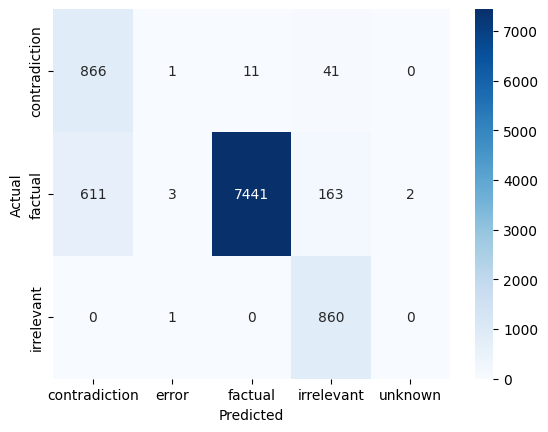

In [14]:
sns.heatmap(conf_matrix_pd, annot=True, fmt='d', cmap='Blues')

In [15]:
from sklearn.metrics import classification_report

report = classification_report(
    results_train_1['actual_category'].str.lower(),
    results_train_1['judgment_category'].str.lower()
)

print(report)

               precision    recall  f1-score   support

contradiction       0.59      0.94      0.72       919
        error       0.00      0.00      0.00         0
      factual       1.00      0.91      0.95      8220
   irrelevant       0.81      1.00      0.89       861
      unknown       0.00      0.00      0.00         0

     accuracy                           0.92     10000
    macro avg       0.48      0.57      0.51     10000
 weighted avg       0.94      0.92      0.92     10000



/home/azureuser/.akshara_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/azureuser/.akshara_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/azureuser/.akshara_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


The LLM judge has perfect recall for irrelevant responses, but preceision of 0.81, indicating that it identifies all irrelevant cases, but around 20% of cases predicted as irrelevant actually belong to other classes.

The factual class shows precision of 1, and recall of 0.91, indicating that all predicted factual classes are correct, but it missed about 10% of factual classes.

Contradiction class has precision of 0.59, we see that around 40% of predicted positives actually belong to factual class. The recall is 0.94.

In [ ]:
results_train_1['correct_judgment'] = results_train_1['actual_category'].str.lower() == results_train_1['judgment_category'].str.lower()
results_train_1.to_csv('llm_judge_evaluation_results_train_10k.csv', index=False)

In [1]:
import pandas as pd
results_train_1=pd.read_csv('llm_judge_evaluation_results_train_10k.csv')

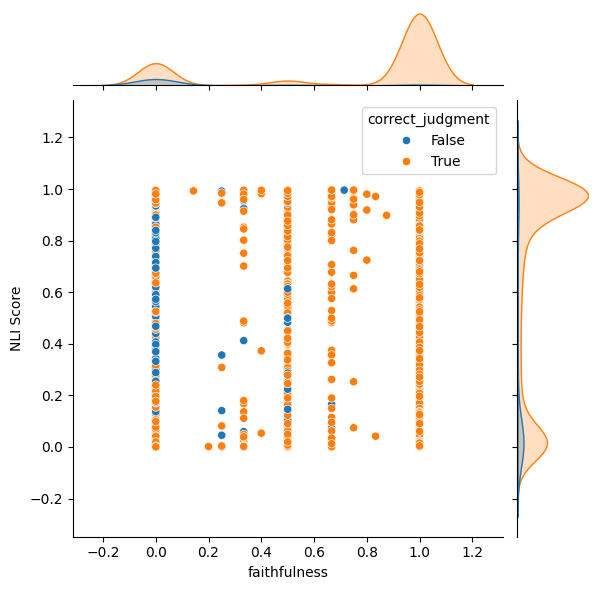

In [5]:
sns.jointplot(
    data=results_train_1,
    x='faithfulness',
    y='NLI Score',
    hue='correct_judgment',
    kind='scatter'
)


We see that the LLM produces correct judgement for higher faithfulness scores, and most incorrect judgements are for low faithfulness scores (around 0), and mid to low NLI scores.

<Axes: xlabel='correct_judgment', ylabel='count'>

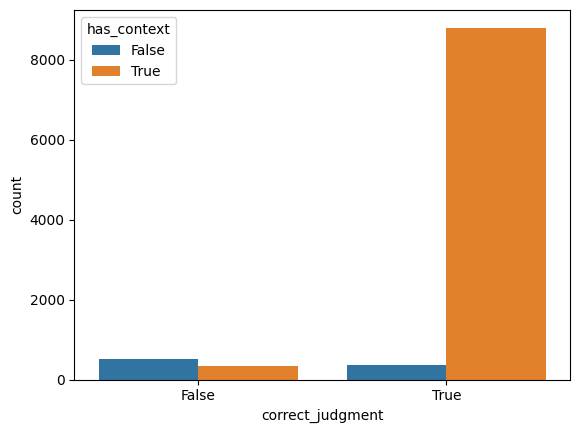

In [11]:
sns.countplot(data=results_train_1, x="correct_judgment", hue="has_context")

<Axes: xlabel='actual_category,has_context'>

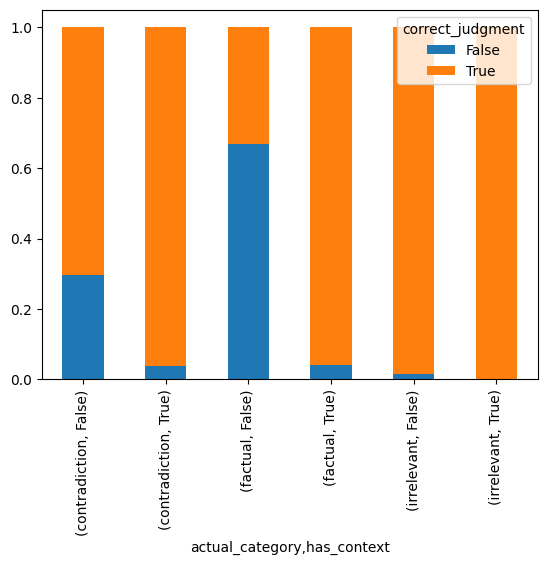

In [12]:
ct = pd.crosstab(
    [results_train_1['actual_category'], results_train_1['has_context']],
    results_train_1['correct_judgment'],
    normalize='index'
)

ct.plot(kind="bar", stacked=True)


From the bar plot of actual categories and whether the question has a reference context, We see that the proportion of incorrect judgements is more when there is no reference context given.
Especially when actual class is factual. This suggests that the LLM judge needs improvement in judging factuality when no reference context is given.

## Improved LLM Judge

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
train_data=pd.read_csv('train_with_faithfulness_scores.csv')
test_df=train_data.loc[:, ['question','context','answer', 'NLI Score', 'faithfulness']]
actual_categories = train_data.loc[:, 'type']
test_df.head()

,question,context,answer,NLI Score,faithfulness
0,In what year did Parliament pass a notable law...,During the Hundred Years' War a French attack ...,"In 1512, Parliament passed a significant act t...",0.962941,1.0
1,Who established early settlements in Florida,"""By May 1539, Conquistador Hernando de Soto sk...",The Spanish and French were the ones who estab...,0.856577,1.0
2,When do monsoons traditionally happen in Punjab?,The onset of the southwest monsoon is anticipa...,"Traditionally, monsoons in Punjab are expected...",0.963583,0.5
3,Who made the requests for Kondo to use orchest...,Media requests at the trade show prompted Kond...,The media made the requests for Kondo to use o...,0.933083,0.0
4,How many inventors came up with electric lamps...,In addressing the question of who invented the...,According to historians Robert Friedel and Pau...,0.995961,1.0


In [5]:
from dotenv import load_dotenv, find_dotenv
import os
import pandas as pd
dotenv_path = find_dotenv()
if dotenv_path:
    # Clear variables loaded by previous calls to load_dotenv, if necessary
    # (load_dotenv typically doesn't overwrite existing variables by default)
    # The following forces a reload and overwrite:
    load_dotenv(dotenv_path, override=True) 
    print("Environment variables reloaded.")
else:
    print(".env file not found.")

Environment variables reloaded.


In [6]:
# Configuration 
ENDPOINT = os.getenv('ENDPOINT_URL')
API_KEY = os.getenv('API_KEY_AZURE')
API_VERSION = "2024-12-01-preview"
DEPLOYMENT = "gpt-4o"  # Your deployment name

### Named Entity Recognition

- Named Entity Recognition (NER) is a natural language processing technique that automatically finds and labels important real‑world items in text, such as people, organizations, locations, dates, and numerical quantities. 

- Named Entity Recognition (NER) helps turn “factuality” into concrete, checkable units (entities + attributes) that the LLM judge can verify. 

- We used GLiNER (Generalist and Lightweight Model for Named Entity Recognition), a framework that provides several pretrained models capable of performing zero-shot NER


In [4]:
from gliner import GLiNER

# Initialize GLiNER with the base model
model = GLiNER.from_pretrained("urchade/gliner_medium-v2.1")

# Sample text for entity prediction
text = """
Cristiano Ronaldo dos Santos Aveiro (Portuguese pronunciation: [kɾiʃˈtjɐnu ʁɔˈnaldu]; born 5 February 1985) is a Portuguese professional footballer who plays as a forward for and captains both Saudi Pro League club Al Nassr and the Portugal national team. Widely regarded as one of the greatest players of all time, Ronaldo has won five Ballon d'Or awards,[note 3] a record three UEFA Men's Player of the Year Awards, and four European Golden Shoes, the most by a European player. He has won 33 trophies in his career, including seven league titles, five UEFA Champions Leagues, the UEFA European Championship and the UEFA Nations League. Ronaldo holds the records for most appearances (183), goals (140) and assists (42) in the Champions League, goals in the European Championship (14), international goals (128) and international appearances (205). He is one of the few players to have made over 1,200 professional career appearances, the most by an outfield player, and has scored over 850 official senior career goals for club and country, making him the top goalscorer of all time.
"""

# Labels for entity prediction
# Most GLiNER models should work best when entity types are in lower case or title case
labels = ["Person", "Award", "Date", "Competitions", "Teams"]

# Perform entity prediction
entities = model.predict_entities(text, labels, threshold=0.5)

# Display predicted entities and their labels
for entity in entities:
    print(entity["text"], "=>", entity["label"])

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 73843.38it/s]
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Cristiano Ronaldo dos Santos Aveiro => Person
5 February 1985 => Date
Portugal national team => Teams
Ballon d'Or => Award
UEFA Men's Player of the Year Awards => Award
European Golden Shoes => Award
UEFA Champions Leagues => Competitions
UEFA European Championship => Competitions
UEFA Nations League => Competitions
European Championship => Competitions


### LLM Judge with NER for Claims verification

Major steps of improved LLM judge:

- Entity extraction (GLiNER model + regex)

- Claim generation from entities

- LLM-based verification of claims against context for factuality

- Fallback classification (if LLM fails or no entities): based on faithfulness and NLI scores

- Final judgment assembly

```mermaid
flowchart LR
    A[Start Evaluation] --> B[Input: Question, Context, Answer, Metrics]

    %% Entity Extraction (C, D, E merged into two nodes)
    B --> C[Extract entities, numbers & quantities]
    C --> E[Merge & deduplicate entities]

    %% Decision: Any entities?
    E --> F{Entities found?}

    %% Claim Generation (G + H merged)
    F -- Yes --> H[Generate claims & verification prompt]

    %% LLM Verification
    H --> I[Call Azure OpenAI LLM]
    I --> J{LLM response valid?}

    %% Parse or fallback
    J -- Yes --> K[Parse CATEGORY & CONFIDENCE]
    J -- No --> L[Fallback classification metrics-based]

    %% No Entities Path (reuse same fallback node)
    F -- No --> L

    %% Final Judgment Assembly
    K --> N[Assemble final judgment]
    L --> N

    %% Output
    N --> O[Output: CATEGORY, CONFIDENCE, Metadata]
    O --> P[End Evaluation]
```

In [7]:
import pandas as pd
from openai import AzureOpenAI
from typing import List, Dict, Optional, Tuple
import time
import re
from gliner import GLiNER


class EntityExtractor:
    def __init__(self, model_name: str = "urchade/gliner_medium-v2.1"):
        """
        Initialize GLiNER model for entity extraction
        
        Args:
            model_name: GLiNER model to use (default: gliner_medium-v2.1)
        """
        print(f"Loading GLiNER model: {model_name}...")
        self.model = GLiNER.from_pretrained(model_name)
        
        # Define entity labels for extraction
        self.entity_labels = [
            "person", "organization", "location", "product", "event",
            "date", "time", "money", "percentage", "quantity", "number",
            "email", "phone", "url"
        ]
    
    def normalize_entity(self, text: str, entity_type: str) -> str:
        """Normalize entity text for better comparison"""
        normalized = text.strip()
        
        # Convert to lowercase for non-proper nouns
        if entity_type in ["date", "time", "money", "percentage", "quantity", "number"]:
            normalized = normalized.lower()
        
        # Remove extra whitespace
        normalized = re.sub(r'\s+', ' ', normalized)
        
        return normalized
    
    def extract_entities(self, text: str, threshold: float = 0.3) -> List[Dict]:
        """Extract entities from text using GLiNER"""
        if not text or pd.isna(text) or str(text).strip() == "":
            return []
        
        # Extract entities using GLiNER
        entities = self.model.predict_entities(
            str(text), 
            self.entity_labels, 
            threshold=threshold
        )
        
        # Format entities
        formatted_entities = []
        for entity in entities:
            formatted_entities.append({
                'text': entity['text'],
                'type': entity['label'],
                'normalized': self.normalize_entity(entity['text'], entity['label']),
                'start': entity['start'],
                'end': entity['end'],
                'score': entity.get('score', 1.0)
            })
        
        # Sort by position in text
        formatted_entities.sort(key=lambda x: x['start'])
        
        return formatted_entities
    
    def extract_numbers_and_quantities(self, text: str) -> List[Dict]:
        """Extract numbers and quantities using regex as supplement to GLiNER"""
        if not text or pd.isna(text):
            return []
        
        entities = []
        
        # Pattern for numbers with units
        number_patterns = [
            (r'\b\d+(?:\.\d+)?%', 'percentage'),
            (r'\$\d+(?:,\d{3})*(?:\.\d{2})?(?:\s*(?:million|billion|trillion|thousand))?', 'money'),
            (r'\b\d+(?:,\d{3})*(?:\.\d+)?\s*(?:kg|km|miles|meters|pounds|tons|gallons|liters)', 'quantity'),
            (r'\b\d{4}(?:s)?(?:\s*-\s*\d{4})?', 'date'),  # Years like 1920s, 1990-2000
            (r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2}(?:,\s*\d{4})?', 'date'),
            (r'\b\d+(?:,\d{3})*(?:\.\d+)?', 'number')  # General numbers
        ]
        
        for pattern, entity_type in number_patterns:
            for match in re.finditer(pattern, str(text), re.IGNORECASE):
                entities.append({
                    'text': match.group(),
                    'type': entity_type,
                    'normalized': match.group().lower().strip(),
                    'start': match.start(),
                    'end': match.end(),
                    'score': 1.0
                })
        
        return entities


class ClaimGenerator:
    """Generate atomic claims from text with entity context"""
    
    @staticmethod
    def generate_entity_claims(text: str, entities: List[Dict]) -> List[Dict]:
        """Generate claim snippets for each entity found in text"""
        claims = []
        
        for entity in entities:
            # Get context around entity (30 chars before and after)
            start = max(0, entity['start'] - 30)
            end = min(len(text), entity['end'] + 30)
            context_snippet = text[start:end].strip()
            
            # Extract the sentence containing the entity
            sentences = re.split(r'[.!?]+', text)
            entity_sentence = None
            for sentence in sentences:
                if entity['text'] in sentence:
                    entity_sentence = sentence.strip()
                    break
            
            # Generate claim based on entity type
            if entity['type'] in ['person', 'organization', 'location', 'product']:
                claim_text = f"The answer mentions {entity['type']} '{entity['text']}'"
            elif entity['type'] in ['date', 'time']:
                claim_text = f"The answer states a {entity['type']} of '{entity['text']}'"
            elif entity['type'] in ['money', 'percentage', 'quantity', 'number']:
                claim_text = f"The answer provides a {entity['type']} value of '{entity['text']}'"
            else:
                claim_text = f"The answer refers to '{entity['text']}'"
            
            # Add sentence context if available
            if entity_sentence:
                claim_text += f" in the context: \"{entity_sentence}\""
            
            claims.append({
                'entity': entity,
                'claim_text': claim_text,
                'context_snippet': context_snippet,
                'sentence': entity_sentence or context_snippet
            })
        
        return claims


class EntityBasedLLMJudge:
    def __init__(self, endpoint: str, api_key: str, api_version: str, deployment: str):
        """
        Initialize the Entity-based LLM Judge
        
        Args:
            endpoint: Azure OpenAI endpoint URL
            api_key: API key for authentication
            api_version: API version
            deployment: Model deployment name
        """
        self.endpoint = endpoint
        self.api_key = api_key
        self.api_version = api_version
        self.deployment = deployment
        
        self.client = AzureOpenAI(
            api_version=api_version,
            azure_endpoint=endpoint,
            api_key=api_key,
        )
        
        self.entity_extractor = EntityExtractor()
        self.claim_generator = ClaimGenerator()
    
    def create_entity_verification_prompt(self, question: str, context: str, 
                                         answer: str, claims: List[Dict],
                                         nli_score: Optional[float] = None,
                                         faithfulness: Optional[float] = None) -> str:
        """Create prompt for entity-based claim verification"""
        
        # Format claims for prompt
        claims_text = ""
        for i, claim in enumerate(claims, 1):
            entity = claim['entity']
            claims_text += f"\n{i}. **Entity**: {entity['text']} (Type: {entity['type']})\n"
            claims_text += f"   **Claim**: {claim['claim_text']}\n"
            claims_text += f"   **Context in answer**: \"{claim['sentence'][:150]}...\"\n"
        
        if not claims_text:
            claims_text = "\n(No specific entities extracted from the answer)\n"
        
        # Add metric information
        metric_info = ""
        if nli_score is not None or faithfulness is not None:
            metric_info = "\n**Available Metrics:**\n"
            if nli_score is not None:
                metric_info += f"- NLI Entailment Score: {nli_score:.3f} (0=contradiction, 0.5=neutral, 1=entailment)\n"
            if faithfulness is not None:
                metric_info += f"- Faithfulness Score: {faithfulness:.3f} (0=unfaithful, 1=fully faithful)\n"
            
            metric_info += "\n**Metric Interpretation:**\n"
            if nli_score is not None and faithfulness is not None:
                if nli_score > 0.75 and faithfulness > 0.7:
                    metric_info += "- High scores suggest strong alignment - verify lightly, lean toward FACTUAL\n"
                elif nli_score < 0.4 and faithfulness < 0.4:
                    metric_info += "- Low scores WARNING - carefully verify each claim for contradictions\n"
                else:
                    metric_info += "- Mixed/moderate scores - perform thorough verification\n"
            metric_info += "\n"
        
        prompt = f"""You are an expert fact-checker. Verify claims from an AI answer against the reference context and provide ONLY a final category and confidence score.

**Question:** {question}

**Reference Context:** {context}

**AI Answer:** {answer}
{metric_info}
**Extracted Entity Claims to Verify:**
{claims_text}

**Classification Categories:**

1. **FACTUAL**: Answer addresses the question and core information is accurate. Minor wording differences or missing details do NOT make an answer non-factual.

2. **IRRELEVANT**: Answer discusses a COMPLETELY DIFFERENT TOPIC with NO CONNECTION to the question. Should be RARE (<5% of cases). Examples: Q: "When did war end?" A: "Photosynthesis converts sunlight" → IRRELEVANT. DO NOT use for partial/incomplete/wrong answers about the topic.

3. **CONTRADICTION**: Answer addresses the question BUT contains CLEARLY WRONG information - contradicting context or major factual errors.

**Verification Process:**

**Step 1 - Relevance Check:**
Does the answer discuss the SAME TOPIC as the question?
- If YES (even partially, vaguely, or incompletely) → Proceed to Step 2
- If NO (completely different subject) → IRRELEVANT (Stop here, confidence 0.85-0.95)
- When in doubt → Answer is RELEVANT, proceed to Step 2

**Step 2 - Verify Each Claim:**

For each entity/claim above:

**A. Entity Type Check:**
- Is entity type correct? (FBI Director ≠ President = CONTRADICTED)

**B. Numerical/Temporal Check:**
- Dates: Different months/years = CONTRADICTED (May ≠ August)
- Duration: 2x difference = CONTRADICTED (3 months ≠ 6 months)
- Quantities: >30% difference = CONTRADICTED
- Acceptable: "approximately 50" ≈ "50", "early May" ≈ "May"

**C. Low Metrics (<0.4) Investigation:**
- Low scores often indicate paraphrasing, NOT errors
- First check: Do core facts match despite different wording?
- If facts match → SUPPORTED (ignore low scores)
- Only mark CONTRADICTED if you find SPECIFIC wrong information
- Low scores alone are NOT sufficient for CONTRADICTION

**Claim Status:**
- SUPPORTED: Matches context (allow paraphrasing)
- CONTRADICTED: Wrong entity/date/number/fact
- NOT_MENTIONED: Not in context (not necessarily wrong)

**Step 3 - Overall Decision:**

If ANY claim CONTRADICTED → **CONTRADICTION**
If all claims SUPPORTED or NOT_MENTIONED:
  - Check for entity type mismatches, wrong numbers/dates
  - If found → **CONTRADICTION**
  - If not found → **FACTUAL**
  - When in doubt between FACTUAL and CONTRADICTION → Choose **FACTUAL**

**Critical Rules:**
- **Context First**: Verify ONLY against context if present. If no context is present, use general knowledge cautiously to verify claims.
- **Allow Paraphrasing**: "begins in May" ≈ "anticipated by May" = SUPPORTED
- **Precision on Entities**: "FBI Director" ≠ "President" = CONTRADICTED
- **Numerical Accuracy**: "3 months" ≠ "6 months" = CONTRADICTED
- **Use Metrics as Guidance**:
  * High NLI (>0.75) + High Faithfulness (>0.7) → Lean FACTUAL unless clear contradiction
  * Low NLI (<0.4) + Low Faithfulness (<0.4) → Scrutinize carefully, but paraphrasing can cause low scores
  * Metrics alone don't determine category - verify claims manually

**Examples to Guide Classification:**
    Example 1:
    Q: “What caused the citywide blackout?”
    Context: “Officials reported that a failed transformer led to a cascading power outage across the city.”
    Answer: “The blackout happened because a transformer failure caused widespread power loss.”
    → FACTUAL (Core cause—transformer failure—is correctly preserved without distortion.)

    Example 2:
    Q: “How long did the expedition last?”
    Context: “The expedition lasted just over three months, ending in early September.”
    Answer: “The expedition lasted about six months before it ended.”
    → CONTRADICTION ((Duration is substantially incorrect and conflicts with the context.))

    Example 3:
    Q: "What color is the sky?"
    Context: "The atmosphere scatters blue light..."
    Answer: "Elephants are large mammals with trunks."
    → IRRELEVANT (Doesn't address the question at all)

    Example 4:
    Q: “Why was the policy delayed?”
    Context: “The policy was delayed due to ongoing negotiations between the two parties.”
    Answer: “The policy was delayed because negotiations were still ongoing.”
    → FACTUAL (The answer restates the same causal reason with equivalent wording.)

    Example 5:
    Q: "What is the process called that can increase solar energy in areas further from the equator?"
    Context: [empty/missing]
    Answer: "The process is called photovoltaics."
    Metrics: NLI=0.01, Faithfulness=0.0
    → CONTRADICTION (No context provided, so using general knowledge per Check 5. Photovoltaics is a technology for converting solar energy, not a process to increase it in specific areas. This is factually incorrect based on general knowledge)

    Example 6:
    Q: "When was the Hubble Space Telescope launched?"
    Context: "The Hubble Space Telescope is a space-based observatory developed through a collaboration between NASA and the European Space Agency. It was designed to operate outside Earth’s atmosphere to avoid atmospheric distortion, allowing it to capture high-resolution images of distant galaxies, nebulae, and stars. After years of development and delays following the Challenger disaster, Hubble was finally carried into orbit by the Space Shuttle Discovery during the STS-31 mission. The launch marked a major milestone in space astronomy and led to numerous groundbreaking discoveries, despite early technical issues with its primary mirror that were corrected during a servicing mission."
    Answer: "The Hubble Space Telescope was launched in April, 1990"
    → FACTUAL (The answer correctly states the launch date of the Hubble Space Telescope, which is supported by the context provided.)


**Output Format (ONLY these two lines):**

CATEGORY: [FACTUAL/CONTRADICTION/IRRELEVANT]
CONFIDENCE: [0.0-1.0]"""
        
        return prompt
    
    def call_llm(self, prompt: str, retry_count: int = 3) -> str:
        """Call the Azure OpenAI endpoint with retry logic"""
        for attempt in range(retry_count):
            try:
                response = self.client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a meticulous fact-checker. Verify claims systematically and output ONLY the category and confidence as requested."
                        },
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    max_completion_tokens=100,
                    temperature=0.0,
                    model=self.deployment
                )
                
                return response.choices[0].message.content
            
            except Exception as e:
                print(f"Attempt {attempt + 1}/{retry_count} failed: {e}")
                if attempt < retry_count - 1:
                    time.sleep(2 ** attempt)
                else:
                    print(f"All retry attempts failed. Error: {e}")
                    return None
    
    def parse_verification_response(self, response: str) -> Dict:
        """Parse the LLM's verification response (category and confidence only)"""
        
        if not response:
            return {
                'category': 'FACTUAL',
                'confidence': 0.25,
                'reasoning': 'Empty LLM response - defaulting to FACTUAL'
            }
        
        lines = response.strip().split('\n')
        
        # Parse category and confidence
        category = None
        confidence = None
        
        for line in lines:
            line_upper = line.upper()
            if 'CATEGORY:' in line_upper:
                category = line.split(':', 1)[1].strip().upper()
            elif 'CONFIDENCE:' in line_upper:
                try:
                    confidence = float(line.split(':', 1)[1].strip())
                except ValueError:
                    confidence = None
        
        # Validate category
        valid_categories = ['FACTUAL', 'CONTRADICTION', 'IRRELEVANT']
        if category not in valid_categories:
            category = 'FACTUAL'  # Default to FACTUAL instead of ERROR
            confidence = 0.4
        
        return {
            'category': category,
            'confidence': confidence if confidence is not None else 0.5,
            'reasoning': f'Entity-based verification: {category}'
        }
    
    def fallback_classification(self, nli_score: Optional[float], 
                               faithfulness: Optional[float],
                               num_entities: int,
                               answer: str = "",
                               question: str = "") -> Dict:
        """
        Enhanced fallback classification based on metric scores when LLM fails
        """
        # If both metrics are missing, make best guess based on entities
        if nli_score is None and faithfulness is None:
            if num_entities > 0:
                return {
                    'category': 'FACTUAL',
                    'confidence': 0.4,
                    'reasoning': f'Fallback: No metrics/LLM. Found {num_entities} entities, assuming FACTUAL.'
                }
            else:
                # No entities, check basic relevance
                if answer and question:
                    answer_words = set(answer.lower().split())
                    question_words = set(question.lower().split())
                    common_words = answer_words & question_words
                    if len(common_words) > 2:
                        return {
                            'category': 'FACTUAL',
                            'confidence': 0.3,
                            'reasoning': 'Fallback: No metrics/LLM. Word overlap detected, assuming FACTUAL.'
                        }
                
                return {
                    'category': 'FACTUAL',
                    'confidence': 0.25,
                    'reasoning': 'Fallback: No signals. Defaulting to FACTUAL.'
                }
        
        # Calculate average score from available metrics
        scores = []
        if nli_score is not None:
            scores.append(nli_score)
        if faithfulness is not None:
            scores.append(faithfulness)
        
        avg_score = sum(scores) / len(scores)

        nli_str = f"{nli_score:.3f}" if nli_score is not None else "N/A"
        faith_str = f"{faithfulness:.3f}" if faithfulness is not None else "N/A"

        if avg_score >= 0.75:
            return {
                'category': 'FACTUAL',
                'confidence': min(0.85, 0.70 + (avg_score * 0.2)),
                'reasoning': (
                    f'Fallback: High metrics '
                    f'(NLI={nli_str}, Faith={faith_str}, avg={avg_score:.3f}). '
                    f'Strong evidence for FACTUAL.'
                )
            }

        elif avg_score >= 0.5:
            return {
                'category': 'FACTUAL',
                'confidence': 0.60 + (avg_score - 0.5) * 0.4,
                'reasoning': f'Fallback: Moderate metrics (avg={avg_score:.3f}). Likely paraphrasing. Defaulting to FACTUAL.'
            }
        elif avg_score >= 0.3:
            return {
                'category': 'FACTUAL',
                'confidence': 0.50,
                'reasoning': f'Fallback: Lower-moderate metrics (avg={avg_score:.3f}). Ambiguous. Defaulting to FACTUAL.'
            }
        else:
            return {
                'category': 'CONTRADICTION',
                'confidence': 0.55,
                'reasoning': f'Fallback: Very low metrics (avg={avg_score:.3f}). Likely contradictory information.'
            }
    
    def evaluate_single(self, question: str, context: str, answer: str,
                       nli_score: Optional[float] = None,
                       faithfulness: Optional[float] = None) -> Dict:
        """Evaluate a single answer using entity-based verification"""
        
        # Step 1: Extract entities from answer
        gliner_entities = self.entity_extractor.extract_entities(answer)
        number_entities = self.entity_extractor.extract_numbers_and_quantities(answer)
        
        # Combine and deduplicate entities
        all_entities = gliner_entities + number_entities
        
        # Remove duplicates based on text and position
        unique_entities = []
        seen = set()
        for entity in all_entities:
            key = (entity['text'], entity['start'], entity['end'])
            if key not in seen:
                seen.add(key)
                unique_entities.append(entity)
        
        # Sort by position
        unique_entities.sort(key=lambda x: x['start'])
        
        # Step 2: Generate claims from entities
        claims = self.claim_generator.generate_entity_claims(answer, unique_entities)
        
        # Step 3: Verify claims with LLM
        if len(claims) > 0:
            prompt = self.create_entity_verification_prompt(
                question, context, answer, claims, nli_score, faithfulness
            )
            response = self.call_llm(prompt)
            
            if response:
                judgment = self.parse_verification_response(response)
            else:
                # LLM failed, use enhanced fallback
                judgment = self.fallback_classification(nli_score, faithfulness, len(unique_entities), answer, question)
        else:
            # No entities found - use metrics for classification
            judgment = self.fallback_classification(nli_score, faithfulness, 0, answer, question)
        
        # Add entity information to judgment
        judgment['entities_in_answer'] = unique_entities
        judgment['num_entities'] = len(unique_entities)
        judgment['num_claims'] = len(claims)
        judgment['nli_score'] = nli_score
        judgment['faithfulness'] = faithfulness
        
        return judgment
    
    def evaluate_dataframe(self, df: pd.DataFrame,
                          question_col: str = 'question',
                          context_col: str = 'context',
                          answer_col: str = 'answer',
                          nli_score_col: Optional[str] = 'NLI Score',
                          faithfulness_col: Optional[str] = 'faithfulness',
                          delay: float = 0.5) -> pd.DataFrame:
        """Evaluate all rows in a dataframe using entity-based verification"""
        
        results = []
        fallback_count = 0
        
        for idx, row in df.iterrows():
            print(f"Evaluating row {idx + 1}/{len(df)}...", end=' ')
            
            # Get metric scores if available
            nli_score = row.get(nli_score_col) if nli_score_col and nli_score_col in df.columns else None
            faithfulness = row.get(faithfulness_col) if faithfulness_col and faithfulness_col in df.columns else None
            
            judgment = self.evaluate_single(
                question=row[question_col],
                context=row[context_col],
                answer=row[answer_col],
                nli_score=nli_score,
                faithfulness=faithfulness
            )
            
            results.append(judgment)
            
            # Track fallbacks
            if 'Fallback' in judgment['reasoning']:
                fallback_count += 1
                print(f"⚠️  {judgment['category']} (fallback, {judgment['num_entities']} entities)")
            else:
                print(f"✓ {judgment['category']} ({judgment['num_entities']} entities)")
            
            if idx < len(df) - 1:
                time.sleep(delay)
        
        # Add results to dataframe
        df['judgment_category'] = [r['category'] for r in results]
        df['judgment_confidence'] = [r['confidence'] for r in results]
        df['judgment_reasoning'] = [r['reasoning'] for r in results]
        df['entities_in_answer'] = [r['entities_in_answer'] for r in results]
        df['num_entities'] = [r['num_entities'] for r in results]
        df['num_claims'] = [r['num_claims'] for r in results]
        
        # Print summary
        if fallback_count > 0:
            print(f"\nℹ️  INFO: {fallback_count}/{len(df)} evaluations used fallback classification")
        else:
            print(f"\n✓ All {len(df)} evaluations completed successfully")
        
        return df
    
    def print_entity_summary(self, df: pd.DataFrame, ground_truth_col: Optional[str] = None):
        """Print summary of entity extraction and verification with optional accuracy"""
        print("\n" + "="*70)
        print("ENTITY EXTRACTION & VERIFICATION SUMMARY")
        print("="*70)
        
        # Category distribution
        category_counts = df['judgment_category'].value_counts()
        print("\nCategory Distribution:")
        for category, count in category_counts.items():
            percentage = (count / len(df)) * 100
            avg_confidence = df[df['judgment_category'] == category]['judgment_confidence'].mean()
            print(f"  {category}: {count} ({percentage:.1f}%) | Avg Confidence: {avg_confidence:.3f}")
        
        # Entity statistics
        total_entities = df['num_entities'].sum()
        avg_entities = df['num_entities'].mean()
        total_claims = df['num_claims'].sum()
        
        print(f"\nEntity Extraction:")
        print(f"  Total entities found: {total_entities}")
        print(f"  Average entities per answer: {avg_entities:.2f}")
        print(f"  Total claims generated: {total_claims}")
        
        # Entity type distribution
        all_entity_types = []
        for entities_list in df['entities_in_answer']:
            all_entity_types.extend([e['type'] for e in entities_list])
        
        if all_entity_types:
            from collections import Counter
            entity_type_counts = Counter(all_entity_types)
            print(f"\nEntity Type Distribution:")
            for entity_type, count in entity_type_counts.most_common(10):
                print(f"  {entity_type}: {count}")
        
        # Calculate accuracy if ground truth provided
        if ground_truth_col and ground_truth_col in df.columns:
            print("\n" + "-"*70)
            print("ACCURACY METRICS")
            print("-"*70)
            
            # Normalize ground truth
            df['gt_normalized'] = df[ground_truth_col].str.upper().str.strip()
            df['gt_normalized'] = df['gt_normalized'].replace({
                'CONTRADICTORY': 'CONTRADICTION',
                'INCORRECT': 'CONTRADICTION'
            })
            
            # Calculate accuracy
            correct = (df['judgment_category'] == df['gt_normalized']).sum()
            accuracy = (correct / len(df)) * 100
            
            print(f"\nOverall Accuracy: {correct}/{len(df)} ({accuracy:.2f}%)")
            
            # Per-category accuracy
            print("\nPer-Category Accuracy:")
            for category in ['FACTUAL', 'IRRELEVANT', 'CONTRADICTION']:
                if category in df['gt_normalized'].values:
                    category_df = df[df['gt_normalized'] == category]
                    category_correct = (category_df['judgment_category'] == category).sum()
                    category_total = len(category_df)
                    category_acc = (category_correct / category_total) * 100 if category_total > 0 else 0
                    print(f"  {category}: {category_correct}/{category_total} ({category_acc:.2f}%)")
            
            # Confusion patterns
            print("\nCommon Misclassifications:")
            misclassified = df[df['judgment_category'] != df['gt_normalized']]
            if len(misclassified) > 0:
                confusion = misclassified.groupby(['gt_normalized', 'judgment_category']).size()
                for (true_cat, pred_cat), count in confusion.items():
                    print(f"  {true_cat} → {pred_cat}: {count}")
            else:
                print("  None - Perfect classification!")
        
        print("="*70 + "\n")


    

In [ ]:
#Evaluate on 1000 rows
import time 

# Initialize judge
judge = EntityBasedLLMJudge(
    endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    deployment=DEPLOYMENT
)

    
start_time=time.time()

test_df_subset=test_df.loc[0:1000, ['question','context','answer', 'NLI Score', 'faithfulness']]

df_evaluated = judge.evaluate_dataframe(test_df_subset)
judge.print_entity_summary(df_evaluated)

df_evaluated['actual_category'] = actual_categories[0:1000]

end_time=time.time()
print(f"Total evaluation time for 1000 rows: {end_time - start_time:.2f} seconds")
df_evaluated.to_csv("evaluated_1000_updated_LLM_judge.csv", index=False)

Loading GLiNER model: urchade/gliner_medium-v2.1...


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 62977.54it/s]
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Evaluating row 1/1001... ✓ FACTUAL (5 entities)
Evaluating row 2/1001... ✓ FACTUAL (2 entities)
Evaluating row 3/1001... ✓ CONTRADICTION (3 entities)
Evaluating row 4/1001... ✓ FACTUAL (2 entities)
Evaluating row 5/1001... ✓ FACTUAL (7 entities)
Evaluating row 6/1001... ✓ CONTRADICTION (3 entities)
Evaluating row 7/1001... ✓ FACTUAL (7 entities)
Evaluating row 8/1001... ✓ FACTUAL (4 entities)
Evaluating row 9/1001... ✓ FACTUAL (2 entities)
Evaluating row 10/1001... ✓ IRRELEVANT (4 entities)
Evaluating row 11/1001... ✓ FACTUAL (3 entities)
Evaluating row 12/1001... ✓ FACTUAL (2 entities)
Evaluating row 13/1001... ✓ FACTUAL (2 entities)
Evaluating row 14/1001... ✓ FACTUAL (2 entities)
Evaluating row 15/1001... ✓ FACTUAL (3 entities)
Evaluating row 16/1001... ✓ IRRELEVANT (2 entities)
Evaluating row 17/1001... ✓ CONTRADICTION (3 entities)
Evaluating row 18/1001... ✓ CONTRADICTION (6 entities)
Evaluating row 19/1001... ✓ FACTUAL (3 entities)
Evaluating row 20/1001... ✓ IRRELEVANT (2 entiti

In [17]:
judge.print_entity_summary(df_evaluated, ground_truth_col='actual_category')


ENTITY EXTRACTION & VERIFICATION SUMMARY

Category Distribution:
  FACTUAL: 729 (72.8%) | Avg Confidence: 0.976
  IRRELEVANT: 147 (14.7%) | Avg Confidence: 0.928
  CONTRADICTION: 125 (12.5%) | Avg Confidence: 0.926

Entity Extraction:
  Total entities found: 3222
  Average entities per answer: 3.22
  Total claims generated: 3222

Entity Type Distribution:
  location: 688
  organization: 646
  person: 495
  event: 431
  number: 254
  product: 214
  date: 207
  time: 122
  quantity: 85
  money: 43

----------------------------------------------------------------------
ACCURACY METRICS
----------------------------------------------------------------------

Overall Accuracy: 902/1001 (90.11%)

Per-Category Accuracy:
  FACTUAL: 726/811 (89.52%)
  IRRELEVANT: 87/90 (96.67%)
  CONTRADICTION: 89/99 (89.90%)

Common Misclassifications:
  CONTRADICTION → FACTUAL: 2
  CONTRADICTION → IRRELEVANT: 8
  FACTUAL → CONTRADICTION: 33
  FACTUAL → IRRELEVANT: 52
  IRRELEVANT → CONTRADICTION: 3



<Axes: xlabel='Predicted', ylabel='Actual'>

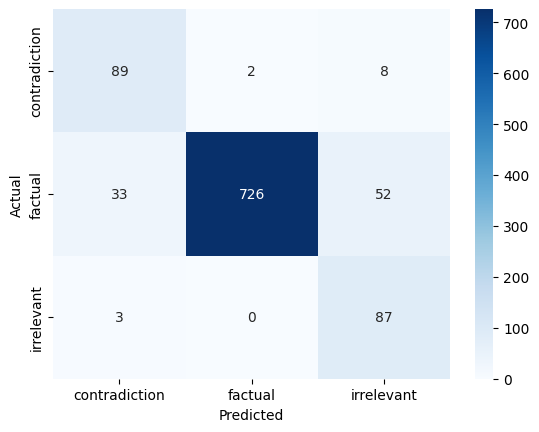

In [18]:
import seaborn as sns
conf_matrix_pd = pd.crosstab(df_evaluated['actual_category'],df_evaluated['judgment_category'].str.lower(), rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_matrix_pd, annot=True, fmt='d', cmap='Blues')

From the confusion matrix, we see that the LLM judge has good distinction between the categories. 

- The Irrelevant class has high recall (96.67%), and Contradiction class has recall of 89.9%.

- Factual class has recall of 89.52%. Few of the factual answers are misclassified as contradiction or irrelevant.

- This is still acceptable since the most of the contradiction and irrelevant cases are predicted without missing, which is important to flag hallucinations and incorrect answers in the context of AI in education

In [19]:
df_evaluated.head()

,question,context,answer,NLI Score,faithfulness,judgment_category,judgment_confidence,judgment_reasoning,entities_in_answer,num_entities,num_claims,actual_category,gt_normalized
0,In what year did Parliament pass a notable law...,During the Hundred Years' War a French attack ...,"In 1512, Parliament passed a significant act t...",0.962941,1.0,FACTUAL,1.00,Entity-based verification: FACTUAL,"[{'text': '1512', 'type': 'date', 'normalized'...",5,5,factual,FACTUAL
1,Who established early settlements in Florida,"""By May 1539, Conquistador Hernando de Soto sk...",The Spanish and French were the ones who estab...,0.856577,1.0,FACTUAL,0.95,Entity-based verification: FACTUAL,"[{'text': 'The Spanish and French', 'type': 'o...",2,2,factual,FACTUAL
2,When do monsoons traditionally happen in Punjab?,The onset of the southwest monsoon is anticipa...,"Traditionally, monsoons in Punjab are expected...",0.963583,0.5,CONTRADICTION,0.95,Entity-based verification: CONTRADICTION,"[{'text': 'monsoons', 'type': 'event', 'normal...",3,3,factual,FACTUAL
3,Who made the requests for Kondo to use orchest...,Media requests at the trade show prompted Kond...,The media made the requests for Kondo to use o...,0.933083,0.0,FACTUAL,0.95,Entity-based verification: FACTUAL,"[{'text': 'The media', 'type': 'organization',...",2,2,factual,FACTUAL
4,How many inventors came up with electric lamps...,In addressing the question of who invented the...,According to historians Robert Friedel and Pau...,0.995961,1.0,FACTUAL,1.00,Entity-based verification: FACTUAL,"[{'text': 'Robert Friedel', 'type': 'person', ...",7,7,factual,FACTUAL


## Save Results on Test dataset

In [5]:
test_data=pd.read_csv("test_data_with_faithfulness_scores.csv")

In [9]:
test_data.head()

,ID,answer,type,context,question,NLI Score,faithfulness
0,1,"In the mid-19th century, the Bronx was referre...",NaN,The Bronx street grid is irregular. Like the n...,What was the Bronx called in the mid-19th cent...,0.978503,1.0
1,2,"Beyoncé's father, Mathew Knowles, began managi...",NaN,NaN,When did Beyoncé begin to manage the girl group?,0.001680,0.0
2,3,Dionysus was similar to the Roman god Bacchus.,NaN,"While the new plebeian nobility made social, p...",To what Roman god was Dionysus similar?,0.520777,1.0
3,4,The most crucial defense in preventing the spr...,NaN,"Techniques like hand washing, wearing gowns, a...",What is the most important defense against the...,0.976116,1.0
4,5,The third largest long term acute care provide...,NaN,The Baylor College of Medicine has annually be...,What is the third largest acute care center in...,0.986577,1.0


In [10]:
import time 

# Initialize judge
judge = EntityBasedLLMJudge(
    endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    deployment=DEPLOYMENT
)

    
start_time=time.time()

test_x=test_data.loc[:, ['question','context','answer', 'NLI Score', 'faithfulness']]

df_evaluated_test = judge.evaluate_dataframe(test_x)

end_time=time.time()
print(f"Total evaluation time for test dataset: {end_time - start_time:.2f} seconds")
df_evaluated_test.to_csv("test_results.csv", index=False)

Loading GLiNER model: urchade/gliner_medium-v2.1...


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 56987.83it/s]
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Evaluating row 1/2000... ✓ FACTUAL (4 entities)
Evaluating row 2/2000... ✓ IRRELEVANT (4 entities)
Evaluating row 3/2000... ✓ FACTUAL (2 entities)
Evaluating row 4/2000... ✓ FACTUAL (1 entities)
Evaluating row 5/2000... ✓ FACTUAL (2 entities)
Evaluating row 6/2000... ✓ FACTUAL (4 entities)
Evaluating row 7/2000... ✓ FACTUAL (2 entities)
Evaluating row 8/2000... ✓ IRRELEVANT (5 entities)
Evaluating row 9/2000... ✓ FACTUAL (4 entities)
Evaluating row 10/2000... ✓ IRRELEVANT (7 entities)
Evaluating row 11/2000... ✓ FACTUAL (2 entities)
Evaluating row 12/2000... ✓ FACTUAL (3 entities)
Evaluating row 13/2000... ✓ IRRELEVANT (5 entities)
Evaluating row 14/2000... ✓ FACTUAL (2 entities)
Evaluating row 15/2000... ✓ FACTUAL (3 entities)
Evaluating row 16/2000... ✓ FACTUAL (3 entities)
Evaluating row 17/2000... ✓ IRRELEVANT (6 entities)
Evaluating row 18/2000... ✓ FACTUAL (3 entities)
Evaluating row 19/2000... ✓ FACTUAL (2 entities)
Evaluating row 20/2000... ✓ FACTUAL (4 entities)
Evaluating row